# 데이터 불러오기

In [185]:
import pandas as pd

df = pd.read_csv("Bank Customer Churn Prediction.csv")
df.head()

,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [186]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customer_id       10000 non-null  int64  
 1   credit_score      10000 non-null  int64  
 2   country           10000 non-null  object 
 3   gender            10000 non-null  object 
 4   age               10000 non-null  int64  
 5   tenure            10000 non-null  int64  
 6   balance           10000 non-null  float64
 7   products_number   10000 non-null  int64  
 8   credit_card       10000 non-null  int64  
 9   active_member     10000 non-null  int64  
 10  estimated_salary  10000 non-null  float64
 11  churn             10000 non-null  int64  
dtypes: float64(2), int64(8), object(2)
memory usage: 937.6+ KB


In [187]:
df.isnull().sum()

customer_id         0
credit_score        0
country             0
gender              0
age                 0
tenure              0
balance             0
products_number     0
credit_card         0
active_member       0
estimated_salary    0
churn               0
dtype: int64

## 불필요 column 삭제

In [188]:
# 불필요 column 삭제
df = df.drop(columns=['customer_id'], axis=1)

# axis = 1(가로, 열 방향)
# 기준축으로 잡은게 열이므로, 열들이 옆으로 늘어서 있는 방향(가로)을 가리킴.

df.columns

Index(['credit_score', 'country', 'gender', 'age', 'tenure', 'balance',
       'products_number', 'credit_card', 'active_member', 'estimated_salary',
       'churn'],
      dtype='object')

In [189]:
df.head()

,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [190]:
print(df.shape)

(10000, 11)


In [158]:
# !uv pip install seaborn
# 통계용 그래프 그리는 라이브러리

## 데이터 상관관계 확인

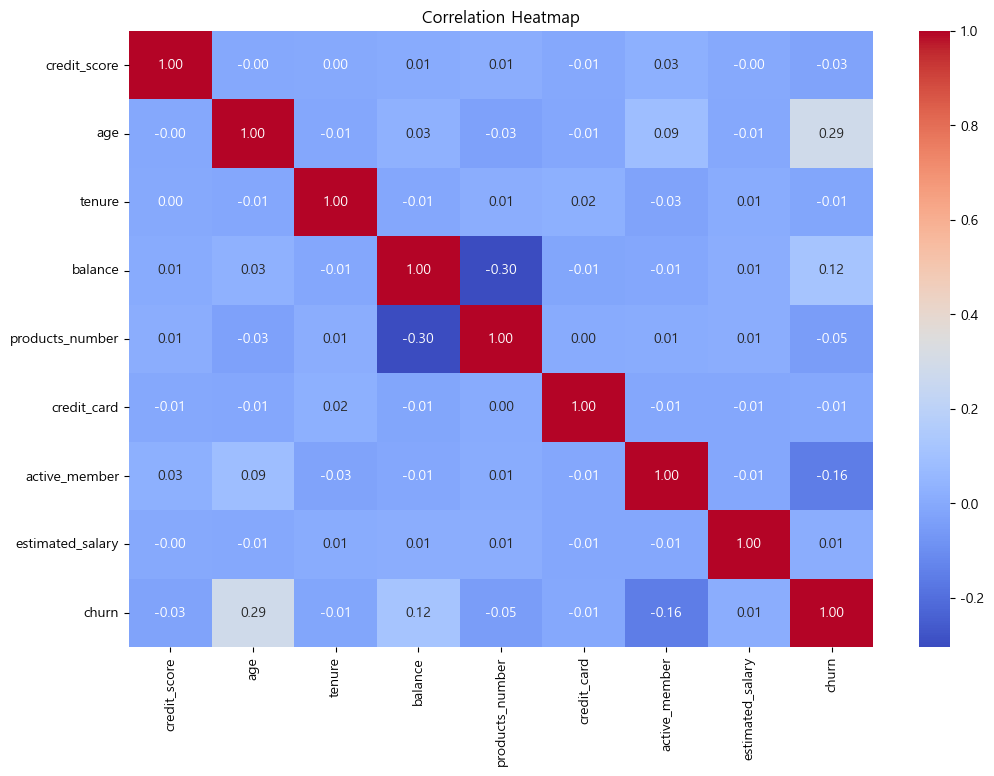

In [191]:
import seaborn as sns
import matplotlib.pyplot as plt
num_df = df.select_dtypes(include=['int64','float64'])
#  상관계수는 숫자끼리만 계산 가능해서 df에서 숫자형 컬럼만 추출. 

corr = num_df.corr()
# 상관계수 행렬 계산

plt.figure(figsize=(12,8))   


sns.heatmap(
    corr, 
    annot=True,       # 각 칸에 숫자 적어주기

    cmap='coolwarm',  # 색 테마 (파랑~빨강)
    # color map의 줄임말, 파랑-흰색-빨강으로 이어지는 색상 스케일
    # 음수는 파랑, 양수는 빨강으로.

    fmt=".2f"         # 소수점 둘째자리까지 표시(format)
)

plt.title('Correlation Heatmap')
plt.show()

# age-churn : 0.29으로 나이가 이탈률에 영향을 끼치는 것으로 볼 수 있음.
# balance - churn : 통장 잔고에 따라 이탈이 있을 가능성이 시사됨.
# active_member - churn : -0.16으로 사용중인 고객은 이탈 가능성이 낮은 것으로 볼 수 있음.

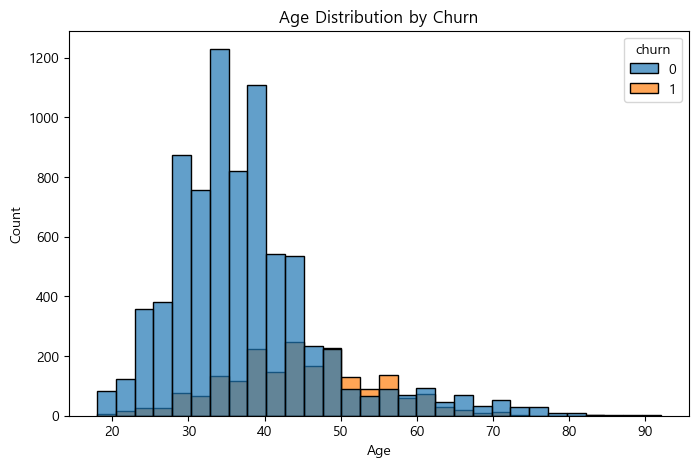

In [192]:
# 나이 분포도에 따른 이탈률

plt.figure(figsize=(8,5))
sns.histplot(
    data=df,
    x='age', # age를 x축으로.
    hue='churn', # churn 값(1과 0)에 따라 색을 다르게.
    bins=30, # 막대 30개
    kde=False, # 분포선 생략
    alpha=0.7 # 막대 투명도 조절(0은 모두 투명해지고 1은 색 구분 안됨)
    )

plt.title('Age Distribution by Churn')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

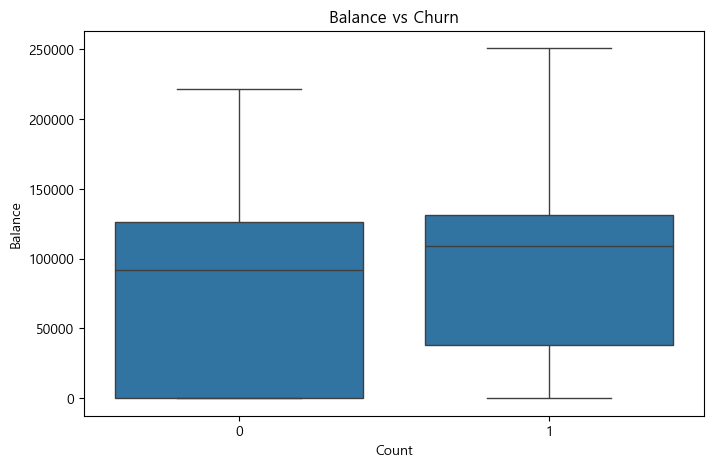

In [193]:
# 잔액에 따른 이탈률

plt.figure(figsize=(8,5))
sns.boxplot(
    data=df,
    x='churn', # 이탈 여부에 따라 그룹을 나눔
    y='balance' # 각 그룹의 잔액 분포를 상자 그래프로 표시
    )

plt.title('Balance vs Churn')
plt.xlabel('Count')
plt.ylabel('Balance')
plt.show()

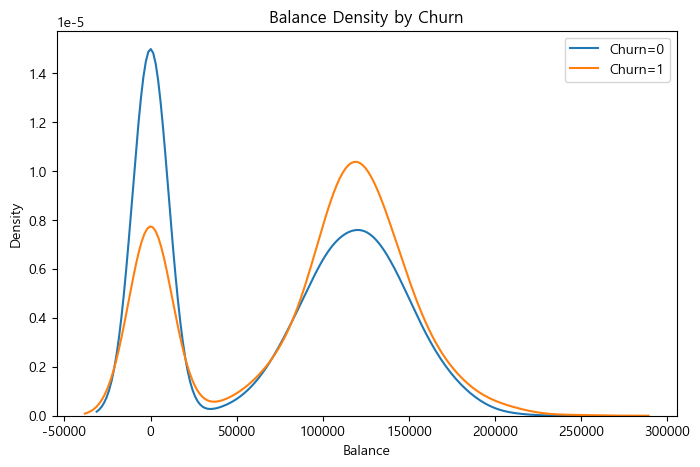

In [194]:

plt.figure(figsize=(8,5))
sns.kdeplot(data=df[df['churn']==0], x='balance', label='Churn=0')
sns.kdeplot(data=df[df['churn']==1], x='balance', label='Churn=1')
plt.title('Balance Density by Churn')
plt.xlabel('Balance')
plt.ylabel('Density')
plt.legend()
plt.show()

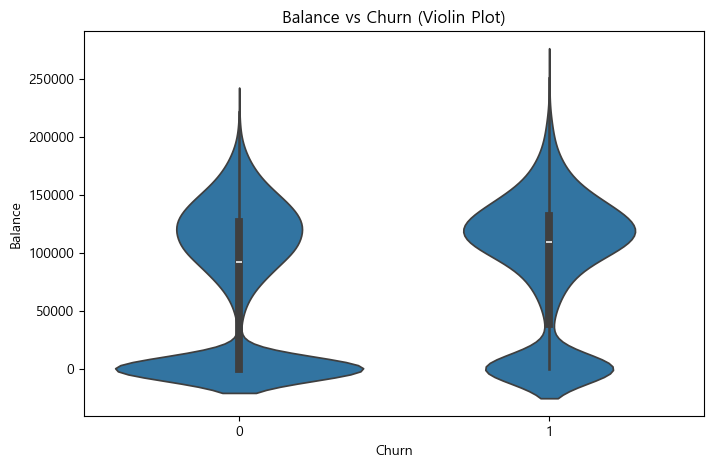

In [195]:
plt.figure(figsize=(8,5))
sns.violinplot(
    data=df,
    x='churn',
    y='balance'
)
plt.title('Balance vs Churn (Violin Plot)')
plt.xlabel('Churn')
plt.ylabel('Balance')
plt.show()

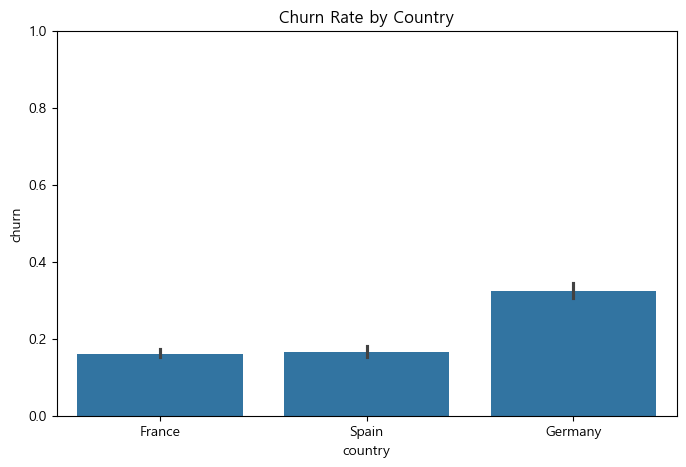

In [196]:
# country별 이탈률
plt.figure(figsize=(8,5))
sns.barplot(data=df, x='country', y='churn', estimator='mean')
# estimator = 'mean' : churn 값의 평균 = 이탈률(%)
plt.title('Churn Rate by Country')
plt.ylim(0,1) # y축의 범위를 0~1로 만듦.
plt.show()

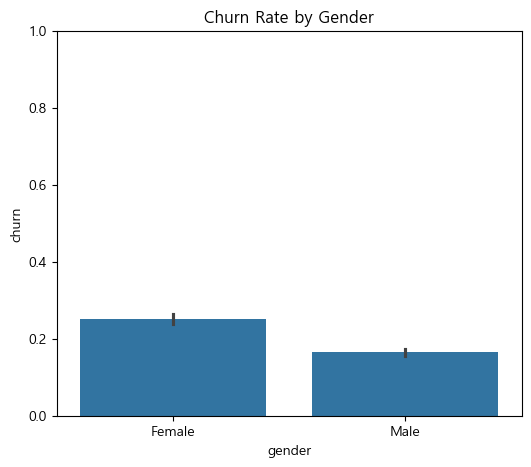

In [197]:
# gender별 이탈률
plt.figure(figsize=(6,5)) 
sns.barplot(data=df, x='gender', y='churn', estimator='mean')
plt.title('Churn Rate by Gender')
plt.ylim(0,1)
plt.show()

## Feature Engineering

In [198]:
import numpy as np
import pandas as pd

def add_features(df):
    df = df.copy()
    
    # 1) Balance Ratio: balance / estimated_salary
    eps = 1e-6
    df["balance_ratio"] = df["balance"] / (df["estimated_salary"] + eps)
    # 극단값 클리핑 (선택)
    df["balance_ratio"] = df["balance_ratio"].clip(-10, 10)
    
    # 2) Credit Usage Rate: balance / credit_score
    df["credit_usage_rate"] = df["balance"] / (df["credit_score"] + eps)
    df["credit_usage_rate"] = df["credit_usage_rate"].clip(-10, 10)
    
    # 3) Tenure 그룹화 (0~3, 3~7, 7~10+)
    df["tenure_bin"] = pd.cut(
        df["tenure"],
        bins=[-1, 3, 7, 10],
        labels=[0, 1, 2]
    ).astype(int)
    
    # 4) 고령 여부
    df["is_senior"] = (df["age"] >= 60).astype(int)
    
    # 5) 잔고 존재 여부
    df["has_balance"] = (df["balance"] > 0).astype(int)
    
    # 6) 상품 수가 많은 고객
    df["many_products"] = (df["products_number"] >= 3).astype(int)
    
    # 7) 장기 고객 여부
    df["long_tenure"] = (df["tenure"] >= 7).astype(int)
    
    # 8) 상호작용 예시: 점수 * 활동성, 잔고 * 활동성
    df["score_active"] = df["credit_score"] * df["active_member"]
    df["balance_active"] = df["balance"] * df["active_member"]
    
    return df


In [199]:
df = add_features(df)

## 범주형 column OHE으로 처리

In [ ]:


# pd.get_dummie : 범주형 변수를 여러 개의 열로 쪼개 줌 
# 'gender'와 'country'를 OHE 방식으로 인코딩.
# dorp_first = True : 중복되는 정보는 하나로, 
# 성별로 예시들면 남성이면 01, 여성이면 10처럼 둘 다 0이거나 1일 수 없음, 
# 두 개의 열을 만들필요 없이 2개였던 열 중 1개만 남겨 남성일때 1 → 여성일때 0 이 되게만듦



In [200]:
df = pd.get_dummies(df, columns=['gender', 'country'], drop_first=True)
df.columns

Index(['credit_score', 'age', 'tenure', 'balance', 'products_number',
       'credit_card', 'active_member', 'estimated_salary', 'churn',
       'balance_ratio', 'credit_usage_rate', 'tenure_bin', 'is_senior',
       'has_balance', 'many_products', 'long_tenure', 'score_active',
       'balance_active', 'gender_Male', 'country_Germany', 'country_Spain'],
      dtype='object')

## X, y 나누기

In [201]:
X = df.drop('churn', axis=1)
y = df['churn']

In [202]:
print(X.shape)
print(y.shape)

X.columns

(10000, 20)
(10000,)


Index(['credit_score', 'age', 'tenure', 'balance', 'products_number',
       'credit_card', 'active_member', 'estimated_salary', 'balance_ratio',
       'credit_usage_rate', 'tenure_bin', 'is_senior', 'has_balance',
       'many_products', 'long_tenure', 'score_active', 'balance_active',
       'gender_Male', 'country_Germany', 'country_Spain'],
      dtype='object')

In [203]:
X.head()

,credit_score,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,balance_ratio,credit_usage_rate,tenure_bin,is_senior,has_balance,many_products,long_tenure,score_active,balance_active,gender_Male,country_Germany,country_Spain
0,619,42,2,0.00,1,1,1,101348.88,0.000000,0.0,0,0,0,0,0,619,0.00,False,False,False
1,608,41,1,83807.86,1,0,1,112542.58,0.744677,10.0,0,0,1,0,0,608,83807.86,False,False,True
2,502,42,8,159660.80,3,1,0,113931.57,1.401375,10.0,2,0,1,1,1,0,0.00,False,False,False
3,699,39,1,0.00,2,0,0,93826.63,0.000000,0.0,0,0,0,0,0,0,0.00,False,False,False
4,850,43,2,125510.82,1,1,1,79084.10,1.587055,10.0,0,0,1,0,0,850,125510.82,False,False,True


In [204]:
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size= 0.40,
    random_state= 42,
    stratify=y
) 

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=25/40, stratify=y_temp, random_state=42
)

print("Train :", X_train.shape)
print("Val   :", X_val.shape)
print("Test  :", X_test.shape)

Train : (6000, 20)
Val   : (1500, 20)
Test  : (2500, 20)


In [205]:
X_train.shape, X_test.shape
# y_train.value_counts(), y_test.value_counts()

((6000, 20), (2500, 20))

In [206]:
X_train.dtypes

credit_score           int64
age                    int64
tenure                 int64
balance              float64
products_number        int64
credit_card            int64
active_member          int64
estimated_salary     float64
balance_ratio        float64
credit_usage_rate    float64
tenure_bin             int64
is_senior              int64
has_balance            int64
many_products          int64
long_tenure            int64
score_active           int64
balance_active       float64
gender_Male             bool
country_Germany         bool
country_Spain           bool
dtype: object

## Scaling

In [207]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

In [208]:
X_train_scaled.shape
# X_test_scaled.shape

(6000, 20)

# 모델 선정

## Lositric Regression

In [96]:
# Logistic Regression (제일 많이 사용되는 baseline)

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix,  recall_score, f1_score, log_loss

# accuracy_score : 모델 정확도 계산
# classification_report : precision / recall / F1 출력
    # precision : 모델이 1이라고 맞춘 것 중에서 진짜 1의 비율
    # recall : 1 중에서 얼마나 맞췄는지
    # F1 : precision + recall 조화 평균
# confusion_matrix : 예측 vs 실제 매트릭스 

model_lr = LogisticRegression(max_iter=1000)
# 학습반복 횟수 1000으로 지정
# 모델이 가진 가중치(weight)를 계속 조정하면서 loss를 최소화 하려는 과정을 숫자만큼 반복함.

model_lr.fit(X_train_scaled, y_train)


pred_val_lr = model_lr.predict(X_val_scaled)
val_acc_lr = accuracy_score(y_val, pred_val_lr)
val_rec_lr = recall_score(y_val, pred_val_lr)
val_f1_lr  = f1_score(y_val, pred_val_lr)

# Validation용 예측 확률
y_val_proba_lr = model_lr.predict_proba(X_val_scaled)[:, 1]
val_loss_lr    = log_loss(y_val, y_val_proba_lr)

print("=== Logistic Regression (Validation) ===")
print("Accuracy :", val_acc_lr)
print("Recall   :", val_rec_lr)
print("F1-score :", val_f1_lr)
print("LogLoss  :", val_loss_lr)
print(classification_report(y_val, pred_val_lr))
print("Confusion Matrix (Val):\n", confusion_matrix(y_val, pred_val_lr))

pred_lr = model_lr.predict(X_test_scaled)

acc_lr = accuracy_score(y_test, pred_lr)
rec_lr = recall_score(y_test, pred_lr)
f1_lr  = f1_score(y_test, pred_lr)

cm_test = confusion_matrix(y_test, pred_lr)

# 4) Log Loss 계산 (Train / Test)
y_train_proba_lr = model_lr.predict_proba(X_train_scaled)[:, 1]
y_test_proba_lr  = model_lr.predict_proba(X_test_scaled)[:, 1]

train_loss = log_loss(y_train, y_train_proba_lr)
test_loss  = log_loss(y_test, y_test_proba_lr)


# 1540 53 → 1540 : 실제 0을 0으로 맞춘 것(TN) / 53 : 실제 0인데 1로 잘못 판단한 것(FP)
# 331 76 → 331 : 실제 1인데 0으로 틀림(FN)★ / 76 : 실제 1인데 1로 맞춤(TP)


=== Logistic Regression (Validation) ===
Accuracy : 0.862
Recall   : 0.4803921568627451
F1-score : 0.5868263473053892
LogLoss  : 0.3473412833589088
              precision    recall  f1-score   support

           0       0.88      0.96      0.92      1194
           1       0.75      0.48      0.59       306

    accuracy                           0.86      1500
   macro avg       0.82      0.72      0.75      1500
weighted avg       0.85      0.86      0.85      1500

Confusion Matrix (Val):
 [[1146   48]
 [ 159  147]]


## DecisionTreeClassifier

In [97]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    recall_score, f1_score, log_loss
)

# ---------------------------------------
# 1) 모델 정의
# ---------------------------------------
model_dt5 = DecisionTreeClassifier(
    max_depth=5,
    class_weight={0:1, 1:2},   # 불균형 보정
    min_samples_leaf=10,
    random_state=42
)


# ---------------------------------------
# 2) Train 데이터로 학습
# ---------------------------------------
model_dt5.fit(X_train_scaled, y_train)


# ---------------------------------------
# 3) Validation 평가
# ---------------------------------------
pred_val_dt5 = model_dt5.predict(X_val_scaled)

val_acc_dt5 = accuracy_score(y_val, pred_val_dt5)
val_rec_dt5 = recall_score(y_val, pred_val_dt5)
val_f1_dt5  = f1_score(y_val, pred_val_dt5)

# Validation LogLoss
y_val_proba_dt5 = model_dt5.predict_proba(X_val_scaled)[:, 1]
val_loss_dt5    = log_loss(y_val, y_val_proba_dt5)

print("=== DecisionTree (Validation) ===")
print("Accuracy :", val_acc_dt5)
print("Recall   :", val_rec_dt5)
print("F1-score :", val_f1_dt5)
print("LogLoss  :", val_loss_dt5)
print(classification_report(y_val, pred_val_dt5))
print("Confusion Matrix (Val):\n", confusion_matrix(y_val, pred_val_dt5))


# ---------------------------------------
# 4) Test 평가
# ---------------------------------------
pred_dt5 = model_dt5.predict(X_test_scaled)

acc_dt5 = accuracy_score(y_test, pred_dt5)
rec_dt5 = recall_score(y_test, pred_dt5)
f1_dt5  = f1_score(y_test, pred_dt5)

print("\n=== DecisionTree (Test) ===")
print("Accuracy :", acc_dt5)
print("Recall   :", rec_dt5)
print("F1-score :", f1_dt5)
print(classification_report(y_test, pred_dt5))
print("Confusion Matrix (Test):\n", confusion_matrix(y_test, pred_dt5))


# ---------------------------------------
# 5) Log Loss (Train/Test)
# ---------------------------------------
y_train_proba_dt5 = model_dt5.predict_proba(X_train_scaled)[:, 1]
y_test_proba_dt5  = model_dt5.predict_proba(X_test_scaled)[:, 1]

train_loss_dt5 = log_loss(y_train, y_train_proba_dt5)
test_loss_dt5  = log_loss(y_test, y_test_proba_dt5)

print("\nTrain Log Loss:", train_loss_dt5)
print("Test Log Loss :", test_loss_dt5)


=== DecisionTree (Validation) ===
Accuracy : 0.842
Recall   : 0.5980392156862745
F1-score : 0.6069651741293532
LogLoss  : 0.4339423504063408
              precision    recall  f1-score   support

           0       0.90      0.90      0.90      1194
           1       0.62      0.60      0.61       306

    accuracy                           0.84      1500
   macro avg       0.76      0.75      0.75      1500
weighted avg       0.84      0.84      0.84      1500

Confusion Matrix (Val):
 [[1080  114]
 [ 123  183]]

=== DecisionTree (Test) ===
Accuracy : 0.836
Recall   : 0.5618860510805501
F1-score : 0.5824847250509165
              precision    recall  f1-score   support

           0       0.89      0.91      0.90      1991
           1       0.60      0.56      0.58       509

    accuracy                           0.84      2500
   macro avg       0.75      0.73      0.74      2500
weighted avg       0.83      0.84      0.83      2500

Confusion Matrix (Test):
 [[1804  187]
 [ 223  

## Random Forest 

In [98]:
# ===============================
# Random Forest
# ===============================

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, recall_score, f1_score, log_loss,
    classification_report, confusion_matrix
)

# 1. 모델 생성 
model_rf = RandomForestClassifier(
    n_estimators=100,       # 트리 개수
    max_depth=5,           
    class_weight={0:1, 1:2},
    random_state=42,
    n_jobs=-1
)

# 2. 학습
model_rf.fit(X_train_scaled, y_train)
# scaling 없어도 되지만 해뒀으니 그대로 사용


# ===============================
# 3. Validation 평가 추가
# ===============================
pred_val_rf = model_rf.predict(X_val_scaled)

val_acc_rf = accuracy_score(y_val, pred_val_rf)
val_rec_rf = recall_score(y_val, pred_val_rf)
val_f1_rf  = f1_score(y_val, pred_val_rf)

# Validation Log Loss
y_val_proba_rf = model_rf.predict_proba(X_val_scaled)[:, 1]
val_loss_rf    = log_loss(y_val, y_val_proba_rf)

print("=== RandomForest (Validation) ===")
print("Accuracy :", val_acc_rf)
print("Recall   :", val_rec_rf)
print("F1-score :", val_f1_rf)
print("LogLoss  :", val_loss_rf)
print(classification_report(y_val, pred_val_rf))
print("Confusion Matrix (Val):\n", confusion_matrix(y_val, pred_val_rf))


# ===============================
# 4. Test 평가 (기존 코드 유지)
# ===============================
pred_rf = model_rf.predict(X_test_scaled)

acc_rf = accuracy_score(y_test, pred_rf)
rec_rf = recall_score(y_test, pred_rf)
f1_rf  = f1_score(y_test, pred_rf)

print("\n=== RandomForest (Test) ===")
print("Accuracy:", acc_rf)
print("Recall  :", rec_rf)
print("F1-score:", f1_rf)
print(classification_report(y_test, pred_rf))
print("Confusion Matrix (Test):\n", confusion_matrix(y_test, pred_rf))


# ===============================
# 5. Loss 확인 (Train/Test)
# ===============================
y_train_proba_rf = model_rf.predict_proba(X_train_scaled)[:, 1]
y_test_proba_rf  = model_rf.predict_proba(X_test_scaled)[:, 1]

train_loss_rf = log_loss(y_train, y_train_proba_rf)
test_loss_rf  = log_loss(y_test, y_test_proba_rf)

print("\nTrain Log Loss:", train_loss_rf)
print("Test Log Loss :", test_loss_rf)


=== RandomForest (Validation) ===
Accuracy : 0.8546666666666667
Recall   : 0.5163398692810458
F1-score : 0.5917602996254682
LogLoss  : 0.4012337966833913
              precision    recall  f1-score   support

           0       0.88      0.94      0.91      1194
           1       0.69      0.52      0.59       306

    accuracy                           0.85      1500
   macro avg       0.79      0.73      0.75      1500
weighted avg       0.84      0.85      0.85      1500

Confusion Matrix (Val):
 [[1124   70]
 [ 148  158]]

=== RandomForest (Test) ===
Accuracy: 0.8548
Recall  : 0.4950884086444008
F1-score: 0.5813148788927336
              precision    recall  f1-score   support

           0       0.88      0.95      0.91      1991
           1       0.70      0.50      0.58       509

    accuracy                           0.85      2500
   macro avg       0.79      0.72      0.75      2500
weighted avg       0.84      0.85      0.84      2500

Confusion Matrix (Test):
 [[1885  10

## Gradient boosting 

In [99]:
# ===============================
# Gradient Boosting Classifier
# ===============================

from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, recall_score, f1_score, log_loss,
    classification_report, confusion_matrix
)

# 1. 모델 생성
model_gb = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

# 2. 학습
model_gb.fit(X_train_scaled, y_train)


# ===============================
# 3. Validation 평가 
# ===============================
pred_val_gb = model_gb.predict(X_val_scaled)

val_acc_gb = accuracy_score(y_val, pred_val_gb)
val_rec_gb = recall_score(y_val, pred_val_gb)
val_f1_gb  = f1_score(y_val, pred_val_gb)

# Validation LogLoss
y_val_proba_gb = model_gb.predict_proba(X_val_scaled)[:, 1]
val_loss_gb    = log_loss(y_val, y_val_proba_gb)

print("=== GradientBoosting (Validation) ===")
print("Accuracy :", val_acc_gb)
print("Recall   :", val_rec_gb)
print("F1-score :", val_f1_gb)
print("LogLoss  :", val_loss_gb)
print(classification_report(y_val, pred_val_gb))
print("Confusion Matrix (Val):\n", confusion_matrix(y_val, pred_val_gb))


# ===============================
# 4. Test 평가
# ===============================
pred_gb = model_gb.predict(X_test_scaled)

acc_gb = accuracy_score(y_test, pred_gb)
rec_gb = recall_score(y_test, pred_gb)
f1_gb  = f1_score(y_test, pred_gb)

print("\n=== GradientBoosting (Test) ===")
print("Accuracy:", acc_gb)
print("Recall  :", rec_gb)
print("F1-score:", f1_gb)
print(classification_report(y_test, pred_gb))
print("Confusion Matrix (Test):\n", confusion_matrix(y_test, pred_gb))


# ===============================
# 5. Log Loss (Train/Test)
# ===============================
y_train_proba_gb = model_gb.predict_proba(X_train_scaled)[:, 1]
y_test_proba_gb  = model_gb.predict_proba(X_test_scaled)[:, 1]

train_loss_gb = log_loss(y_train, y_train_proba_gb)
test_loss_gb  = log_loss(y_test, y_test_proba_gb)

print("\nTrain Log Loss:", train_loss_gb)
print("Test Log Loss :", test_loss_gb)


=== GradientBoosting (Validation) ===
Accuracy : 0.8733333333333333
Recall   : 0.5326797385620915
F1-score : 0.6317829457364341
LogLoss  : 0.3214791022619898
              precision    recall  f1-score   support

           0       0.89      0.96      0.92      1194
           1       0.78      0.53      0.63       306

    accuracy                           0.87      1500
   macro avg       0.83      0.75      0.78      1500
weighted avg       0.87      0.87      0.86      1500

Confusion Matrix (Val):
 [[1147   47]
 [ 143  163]]

=== GradientBoosting (Test) ===
Accuracy: 0.8656
Recall  : 0.47544204322200395
F1-score: 0.5902439024390244
              precision    recall  f1-score   support

           0       0.88      0.97      0.92      1991
           1       0.78      0.48      0.59       509

    accuracy                           0.87      2500
   macro avg       0.83      0.72      0.75      2500
weighted avg       0.86      0.87      0.85      2500

Confusion Matrix (Test):
 [

## XGBoost

In [100]:
# ===============================
# XGBoost
# ===============================

import xgboost as xgb
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    log_loss, recall_score, f1_score, precision_score
)

# 1. 모델 생성
model_xgb = xgb.XGBClassifier(
    n_estimators=500,
    max_depth=3,
    learning_rate=0.03,
    subsample=0.6,
    colsample_bytree=0.6,
    random_state=42,
    eval_metric='logloss',
    scale_pos_weight=4,
    min_child_weight=20
)

# 2. Train 학습
model_xgb.fit(X_train_scaled, y_train)


# ===============================
# 3. Validation 평가
# ===============================

# Validation 예측 확률
y_val_proba_xgb = model_xgb.predict_proba(X_val_scaled)[:, 1]

# threshold 적용 (너가 0.45 쓰고 있어서 그대로 적용)
threshold = 0.45
pred_val_xgb = (y_val_proba_xgb >= threshold).astype(int)

# Validation 지표
val_acc_xgb  = accuracy_score(y_val, pred_val_xgb)
val_rec_xgb  = recall_score(y_val, pred_val_xgb)
val_f1_xgb   = f1_score(y_val, pred_val_xgb)
val_prec_xgb = precision_score(y_val, pred_val_xgb)
val_loss_xgb = log_loss(y_val, y_val_proba_xgb)

print("=== XGBoost (Validation) ===")
print("Accuracy :", val_acc_xgb)
print("Precision:", val_prec_xgb)
print("Recall   :", val_rec_xgb)
print("F1-score :", val_f1_xgb)
print("LogLoss  :", val_loss_xgb)
print(classification_report(y_val, pred_val_xgb))
print("Confusion Matrix (Val):\n", confusion_matrix(y_val, pred_val_xgb))


# ===============================
# 4. Test 평가
# ===============================

# Test 예측 확률
y_test_proba_xgb = model_xgb.predict_proba(X_test_scaled)[:, 1]

# threshold 적용 (동일하게 0.45)
pred_xgb = (y_test_proba_xgb >= threshold).astype(int)

acc_xgb  = accuracy_score(y_test, pred_xgb)
rec_xgb  = recall_score(y_test, pred_xgb)
f1_xgb   = f1_score(y_test, pred_xgb)
prec_xgb = precision_score(y_test, pred_xgb)

print("\n=== XGBoost (Test) ===")
print("Accuracy :", acc_xgb)
print("Precision:", prec_xgb)
print("Recall   :", rec_xgb)
print("F1-score :", f1_xgb)
print(classification_report(y_test, pred_xgb))
print("Confusion Matrix (Test):\n", confusion_matrix(y_test, pred_xgb))


# ===============================
# 5. Log Loss (Train/Test)
# ===============================
y_train_proba_xgb = model_xgb.predict_proba(X_train_scaled)[:, 1]

train_loss_xgb = log_loss(y_train, y_train_proba_xgb)
test_loss_xgb  = log_loss(y_test, y_test_proba_xgb)

print("\nTrain Log Loss:", train_loss_xgb)
print("Test Log Loss :", test_loss_xgb)


=== XGBoost (Validation) ===
Accuracy : 0.7706666666666667
Precision: 0.4646840148698885
Recall   : 0.8169934640522876
F1-score : 0.5924170616113744
LogLoss  : 0.4384915303140238
              precision    recall  f1-score   support

           0       0.94      0.76      0.84      1194
           1       0.46      0.82      0.59       306

    accuracy                           0.77      1500
   macro avg       0.70      0.79      0.72      1500
weighted avg       0.84      0.77      0.79      1500

Confusion Matrix (Val):
 [[906 288]
 [ 56 250]]

=== XGBoost (Test) ===
Accuracy : 0.7592
Precision: 0.4491803278688525
Recall   : 0.8074656188605108
F1-score : 0.577247191011236
              precision    recall  f1-score   support

           0       0.94      0.75      0.83      1991
           1       0.45      0.81      0.58       509

    accuracy                           0.76      2500
   macro avg       0.69      0.78      0.70      2500
weighted avg       0.84      0.76      0.78

## light GBM

In [101]:
# light GBM
# !uv pip install lightgbm

import lightgbm as lgb
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, log_loss, recall_score, f1_score

model_lgb = lgb.LGBMClassifier(
    n_estimators=500,
    learning_rate=0.03,
    max_depth=-1,
    num_leaves=64,
    min_child_samples=20,
    subsample=0.8,
    colsample_bytree=0.7,
    random_state=42,
    class_weight={0:1, 1:5}
)

model_lgb.fit(X_train_scaled, y_train)

pred_lgb = model_lgb.predict(X_test_scaled)

acc_lgb = accuracy_score(y_test, pred_lgb)
rec_lgb = recall_score(y_test, pred_lgb)
f1_lgb = f1_score(y_test, pred_lgb)

print("Accuracy:", accuracy_score(y_test, pred_lgb))
print(classification_report(y_test, pred_lgb))
print(confusion_matrix(y_test, pred_lgb))

y_train_proba_lgb = model_lgb.predict_proba(X_train_scaled)[:, 1]
y_test_proba_lgb  = model_lgb.predict_proba(X_test_scaled)[:, 1]
loss_lgb = log_loss(y_test, y_test_proba_lgb)

print("Train Loss:", log_loss(y_train, y_train_proba_lgb))
print("Test Loss :", log_loss(y_test, y_test_proba_lgb))


[LightGBM] [Info] Number of positive: 1222, number of negative: 4778
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001449 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1643
[LightGBM] [Info] Number of data points in the train set: 6000, number of used features: 20
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.561168 -> initscore=0.245905
[LightGBM] [Info] Start training from score 0.245905
Accuracy: 0.832
              precision    recall  f1-score   support

           0       0.90      0.89      0.89      1991
           1       0.58      0.62      0.60       509

    accuracy                           0.83      2500
   macro avg       0.74      0.75      0.75      2500
weighted avg       0.84      0.83      0.83      2500

[[1766  225]
 [ 195  314]]
Train Loss: 0.10627591047347863
Test Loss : 0.39388472863575225


c:\Users\Playdata\Documents\SKN21\JYS\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\Playdata\Documents\SKN21\JYS\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\Playdata\Documents\SKN21\JYS\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [102]:
# ===============================
# LightGBM 
# ===============================

import lightgbm as lgb
from sklearn.metrics import (
    accuracy_score, precision_score, classification_report,
    confusion_matrix, log_loss, recall_score, f1_score
)

# 1. 모델 생성
model_lgb = lgb.LGBMClassifier(
    n_estimators=500,
    learning_rate=0.04,
    max_depth=1,
    num_leaves=64,
    min_child_samples=20,
    subsample=0.8,
    colsample_bytree=0.7,
    random_state=42,
    class_weight={0:1, 1:4}
)

# 2. Train 학습
model_lgb.fit(X_train_scaled, y_train)


# ===============================
# 3. Validation 평가 
# ===============================

# Validation 예측 확률
y_val_proba_lgb = model_lgb.predict_proba(X_val_scaled)[:, 1]

# threshold 적용 
threshold = 0.45
pred_val_lgb = (y_val_proba_lgb >= threshold).astype(int)

# Validation 지표
val_acc_lgb  = accuracy_score(y_val, pred_val_lgb)
val_rec_lgb  = recall_score(y_val, pred_val_lgb)
val_f1_lgb   = f1_score(y_val, pred_val_lgb)
val_prec_lgb = precision_score(y_val, pred_val_lgb)
val_loss_lgb = log_loss(y_val, y_val_proba_lgb)

print("=== LightGBM (Validation) ===")
print("Accuracy :", val_acc_lgb)
print("Precision:", val_prec_lgb)
print("Recall   :", val_rec_lgb)
print("F1-score :", val_f1_lgb)
print("LogLoss  :", val_loss_lgb)
print(classification_report(y_val, pred_val_lgb))
print("Confusion Matrix (Val):\n", confusion_matrix(y_val, pred_val_lgb))


# ===============================
# 4. Test 평가 
# ===============================

# Test 예측 확률
y_test_proba_lgb = model_lgb.predict_proba(X_test_scaled)[:, 1]

# threshold 적용
pred_lgb = (y_test_proba_lgb >= threshold).astype(int)

acc_lgb  = accuracy_score(y_test, pred_lgb)
rec_lgb  = recall_score(y_test, pred_lgb)
f1_lgb   = f1_score(y_test, pred_lgb)
prec_lgb = precision_score(y_test, pred_lgb)

print("\n=== LightGBM (Test) ===")
print("Accuracy:", acc_lgb)
print("Precision:", prec_lgb)
print("Recall  :", rec_lgb)
print("F1-score:", f1_lgb)
print(classification_report(y_test, pred_lgb))
print("Confusion Matrix (Test):\n", confusion_matrix(y_test, pred_lgb))


# ===============================
# 5. Train/Test LogLoss
# ===============================
y_train_proba_lgb = model_lgb.predict_proba(X_train_scaled)[:, 1]
train_loss_lgb = log_loss(y_train, y_train_proba_lgb)
test_loss_lgb  = log_loss(y_test,  y_test_proba_lgb)

print("\nTrain Log Loss:", train_loss_lgb)
print("Test Log Loss :", test_loss_lgb)


[LightGBM] [Info] Number of positive: 1222, number of negative: 4778
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000388 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1643
[LightGBM] [Info] Number of data points in the train set: 6000, number of used features: 20
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.505690 -> initscore=0.022761
[LightGBM] [Info] Start training from score 0.022761
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, be

c:\Users\Playdata\Documents\SKN21\JYS\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\Playdata\Documents\SKN21\JYS\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\Playdata\Documents\SKN21\JYS\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [103]:
print("=== LightGBM (Validation) ===")
print("Accuracy :", val_acc_lgb)
print("Precision:", val_prec_lgb)
print("Recall   :", val_rec_lgb)
print("F1-score :", val_f1_lgb)
print("LogLoss  :", val_loss_lgb)
print(classification_report(y_val, pred_val_lgb))
print("Confusion Matrix (Val):\n", confusion_matrix(y_val, pred_val_lgb))
print("\n=== LightGBM (Test) ===")
print("Accuracy:", acc_lgb)
print("Precision:", prec_lgb)
print("Recall  :", rec_lgb)
print("F1-score:", f1_lgb)
print(classification_report(y_test, pred_lgb))
print("Confusion Matrix (Test):\n", confusion_matrix(y_test, pred_lgb))
print("\nTrain Log Loss:", train_loss_lgb)
print("Test Log Loss :", test_loss_lgb)

=== LightGBM (Validation) ===
Accuracy : 0.758
Precision: 0.4497354497354497
Recall   : 0.8333333333333334
F1-score : 0.584192439862543
LogLoss  : 0.475865956937769
              precision    recall  f1-score   support

           0       0.95      0.74      0.83      1194
           1       0.45      0.83      0.58       306

    accuracy                           0.76      1500
   macro avg       0.70      0.79      0.71      1500
weighted avg       0.84      0.76      0.78      1500

Confusion Matrix (Val):
 [[882 312]
 [ 51 255]]

=== LightGBM (Test) ===
Accuracy: 0.738
Precision: 0.42331932773109243
Recall  : 0.7917485265225933
F1-score: 0.5516769336071184
              precision    recall  f1-score   support

           0       0.93      0.72      0.81      1991
           1       0.42      0.79      0.55       509

    accuracy                           0.74      2500
   macro avg       0.68      0.76      0.68      2500
weighted avg       0.83      0.74      0.76      2500

Con

## SVM

In [104]:
# ===============================
# SVM (Support Vector Machine)
# ===============================

from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, log_loss
)

# 1. 모델 생성
model_svm = SVC(
    kernel='rbf',          # 기본 RBF 커널
    C=1.0,                 # 규제 정도
    gamma='scale',         # 커널 스케일링
    probability=True,      # ★ predict_proba 사용 가능하게 함
    class_weight={0:1, 1:4},
    random_state=42
)

# 2. Train 학습
model_svm.fit(X_train_scaled, y_train)


# ===============================
# 3. Validation 평가
# ===============================

# Validation 확률값
y_val_proba_svm = model_svm.predict_proba(X_val_scaled)[:, 1]

# threshold 적용
threshold = 0.26
pred_val_svm = (y_val_proba_svm >= threshold).astype(int)

# Validation 지표 출력
val_acc_svm  = accuracy_score(y_val, pred_val_svm)
val_prec_svm = precision_score(y_val, pred_val_svm)
val_rec_svm  = recall_score(y_val, pred_val_svm)
val_f1_svm   = f1_score(y_val, pred_val_svm)
val_loss_svm = log_loss(y_val, y_val_proba_svm)

print("=== SVM (Validation) ===")
print("Accuracy :", val_acc_svm)
print("Precision:", val_prec_svm)
print("Recall   :", val_rec_svm)
print("F1-score :", val_f1_svm)
print("LogLoss  :", val_loss_svm)
print(classification_report(y_val, pred_val_svm))
print("Confusion Matrix (Val):\n", confusion_matrix(y_val, pred_val_svm))


# ===============================
# 4. Test 평가
# ===============================

# Test 확률값
y_test_proba_svm = model_svm.predict_proba(X_test_scaled)[:, 1]

# threshold 적용
pred_svm = (y_test_proba_svm >= threshold).astype(int)

# Test 지표
acc_svm  = accuracy_score(y_test, pred_svm)
prec_svm = precision_score(y_test, pred_svm)
rec_svm  = recall_score(y_test, pred_svm)
f1_svm   = f1_score(y_test, pred_svm)

print("\n=== SVM (Test) ===")
print("Accuracy :", acc_svm)
print("Precision:", prec_svm)
print("Recall   :", rec_svm)
print("F1-score :", f1_svm)
print(classification_report(y_test, pred_svm))
print("Confusion Matrix (Test):\n", confusion_matrix(y_test, pred_svm))


# ===============================
# 5. Train/Test LogLoss
# ===============================
y_train_proba_svm = model_svm.predict_proba(X_train_scaled)[:, 1]
train_loss_svm    = log_loss(y_train, y_train_proba_svm)
test_loss_svm     = log_loss(y_test,  y_test_proba_svm)

print("\nTrain Log Loss:", train_loss_svm)
print("Test  Log Loss:", test_loss_svm)


=== SVM (Validation) ===
Accuracy : 0.8
Precision: 0.5066964285714286
Recall   : 0.7418300653594772
F1-score : 0.6021220159151194
LogLoss  : 0.35663607771138567
              precision    recall  f1-score   support

           0       0.92      0.81      0.87      1194
           1       0.51      0.74      0.60       306

    accuracy                           0.80      1500
   macro avg       0.72      0.78      0.73      1500
weighted avg       0.84      0.80      0.81      1500

Confusion Matrix (Val):
 [[973 221]
 [ 79 227]]

=== SVM (Test) ===
Accuracy : 0.7924
Precision: 0.493368700265252
Recall   : 0.730844793713163
F1-score : 0.5890736342042755
              precision    recall  f1-score   support

           0       0.92      0.81      0.86      1991
           1       0.49      0.73      0.59       509

    accuracy                           0.79      2500
   macro avg       0.71      0.77      0.73      2500
weighted avg       0.83      0.79      0.81      2500

Confusion M

In [105]:
print("=== SVM (Validation) ===")
print("Accuracy :", val_acc_svm)
print("Precision:", val_prec_svm)
print("Recall   :", val_rec_svm)
print("F1-score :", val_f1_svm)
print("LogLoss  :", val_loss_svm)
print(classification_report(y_val, pred_val_svm))
print("Confusion Matrix (Val):\n", confusion_matrix(y_val, pred_val_svm))

=== SVM (Validation) ===
Accuracy : 0.8
Precision: 0.5066964285714286
Recall   : 0.7418300653594772
F1-score : 0.6021220159151194
LogLoss  : 0.35663607771138567
              precision    recall  f1-score   support

           0       0.92      0.81      0.87      1194
           1       0.51      0.74      0.60       306

    accuracy                           0.80      1500
   macro avg       0.72      0.78      0.73      1500
weighted avg       0.84      0.80      0.81      1500

Confusion Matrix (Val):
 [[973 221]
 [ 79 227]]


In [106]:
print("\n=== SVM (Test) ===")
print("Accuracy :", acc_svm)
print("Precision:", prec_svm)
print("Recall   :", rec_svm)
print("F1-score :", f1_svm)
print(classification_report(y_test, pred_svm))
print("Confusion Matrix (Test):\n", confusion_matrix(y_test, pred_svm))



=== SVM (Test) ===
Accuracy : 0.7924
Precision: 0.493368700265252
Recall   : 0.730844793713163
F1-score : 0.5890736342042755
              precision    recall  f1-score   support

           0       0.92      0.81      0.86      1991
           1       0.49      0.73      0.59       509

    accuracy                           0.79      2500
   macro avg       0.71      0.77      0.73      2500
weighted avg       0.83      0.79      0.81      2500

Confusion Matrix (Test):
 [[1609  382]
 [ 137  372]]


## Neural Network

In [107]:
# =====================================
# Neural Network (MLPClassifier)
# =====================================

from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, log_loss
)

# 1. 모델 생성
model_mlp = MLPClassifier(
    hidden_layer_sizes=(64, 32),   # 뉴런 구성
    activation='relu',
    solver='adam',
    alpha=0.00005,                   # L2 규제
    learning_rate_init=0.001,
    max_iter=400,
    random_state=42
)

# 2. 학습
model_mlp.fit(X_train_scaled, y_train)


# =====================================
# 3. Validation 평가
# =====================================

y_val_proba_mlp = model_mlp.predict_proba(X_val_scaled)[:, 1]

threshold = 0.26   
pred_val_mlp = (y_val_proba_mlp >= threshold).astype(int)

val_acc_mlp  = accuracy_score(y_val, pred_val_mlp)
val_prec_mlp = precision_score(y_val, pred_val_mlp)
val_rec_mlp  = recall_score(y_val, pred_val_mlp)
val_f1_mlp   = f1_score(y_val, pred_val_mlp)
val_loss_mlp = log_loss(y_val, y_val_proba_mlp)

print("=== MLP Neural Network (Validation) ===")
print("Accuracy :", val_acc_mlp)
print("Precision:", val_prec_mlp)
print("Recall   :", val_rec_mlp)
print("F1-score :", val_f1_mlp)
print("LogLoss  :", val_loss_mlp)
print(classification_report(y_val, pred_val_mlp))
print("Confusion Matrix (Val):\n", confusion_matrix(y_val, pred_val_mlp))


# =====================================
# 4. Test 평가
# =====================================

y_test_proba_mlp = model_mlp.predict_proba(X_test_scaled)[:, 1]
pred_test_mlp = (y_test_proba_mlp >= threshold).astype(int)

acc_mlp  = accuracy_score(y_test, pred_test_mlp)
prec_mlp = precision_score(y_test, pred_test_mlp)
rec_mlp  = recall_score(y_test, pred_test_mlp)
f1_mlp   = f1_score(y_test, pred_test_mlp)

print("\n=== MLP Neural Network (Test) ===")
print("Accuracy :", acc_mlp)
print("Precision:", prec_mlp)
print("Recall   :", rec_mlp)
print("F1-score :", f1_mlp)
print(classification_report(y_test, pred_test_mlp))
print("Confusion Matrix (Test):\n", confusion_matrix(y_test, pred_test_mlp))


# =====================================
# 5. Train/Test LogLoss
# =====================================
y_train_proba_mlp = model_mlp.predict_proba(X_train_scaled)[:, 1]

train_loss_mlp = log_loss(y_train, y_train_proba_mlp)
test_loss_mlp  = log_loss(y_test, y_test_proba_mlp)

print("\nTrain Log Loss:", train_loss_mlp)
print("Test Log Loss :", test_loss_mlp)


=== MLP Neural Network (Validation) ===
Accuracy : 0.784
Precision: 0.47783251231527096
Recall   : 0.6339869281045751
F1-score : 0.5449438202247191
LogLoss  : 0.7251902886789556
              precision    recall  f1-score   support

           0       0.90      0.82      0.86      1194
           1       0.48      0.63      0.54       306

    accuracy                           0.78      1500
   macro avg       0.69      0.73      0.70      1500
weighted avg       0.81      0.78      0.79      1500

Confusion Matrix (Val):
 [[982 212]
 [112 194]]

=== MLP Neural Network (Test) ===
Accuracy : 0.7708
Precision: 0.45321637426900585
Recall   : 0.6090373280943026
F1-score : 0.5196982397317687
              precision    recall  f1-score   support

           0       0.89      0.81      0.85      1991
           1       0.45      0.61      0.52       509

    accuracy                           0.77      2500
   macro avg       0.67      0.71      0.68      2500
weighted avg       0.80      0.

c:\Users\Playdata\Documents\SKN21\JYS\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (400) reached and the optimization hasn't converged yet.
  warnings.warn(


# 모델 성능 확인

In [209]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, auc, precision_recall_curve
from sklearn.metrics import confusion_matrix
import shap

In [109]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, log_loss,
    classification_report, confusion_matrix,
    roc_curve, roc_auc_score,
    precision_recall_curve, average_precision_score
)

models = {
    "Logistic":          model_lr,
    "DecisionTree":      model_dt5,
    "RandomForest":      model_rf,
    "GradientBoosting":  model_gb,
    "XGBoost":           model_xgb,
    "LightGBM":          model_lgb,
    "SVM":               model_svm,
    "NeuralNet(MLP)":    model_mlp,
}

# 각 모델에 쓸 threshold (원하는 대로 수정해서 사용)
thresholds_for_model = {
    "Logistic":         0.45,
    "DecisionTree":     0.45,
    "RandomForest":     0.45,
    "GradientBoosting": 0.45,
    "XGBoost":          0.45,
    "LightGBM":         0.45,
    "SVM":              0.45,  
    "NeuralNet(MLP)":   0.26,
}


## 모델별 TEST 성능 Table

In [178]:
test_rows = []

for name, model in models.items():
    th = thresholds_for_model[name]
    proba = model.predict_proba(X_test_scaled)[:, 1]
    pred  = (proba >= th).astype(int)

    acc  = accuracy_score(y_test, pred)
    rec  = recall_score(y_test, pred)
    prec = precision_score(y_test, pred, zero_division=0)
    f1   = f1_score(y_test, pred)
    loss = log_loss(y_test, proba)

    test_rows.append({
        "Model": name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1": f1,
        "LogLoss": loss
    })

df_test_results = pd.DataFrame(test_rows).set_index("Model").sort_values("F1", ascending=False)
df_test_results


c:\Users\Playdata\Documents\SKN21\JYS\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


,Accuracy,Precision,Recall,F1,LogLoss
Model,,,,,
GradientBoosting,0.8616,0.734870,0.500982,0.595794,0.330808
RandomForest,0.8500,0.665025,0.530452,0.590164,0.406164
DecisionTree,0.8084,0.522796,0.675835,0.589546,0.404727
SVM,0.8372,0.609442,0.557957,0.582564,0.369325
XGBoost,0.7592,0.449180,0.807466,0.577247,0.451527
LightGBM,0.7380,0.423319,0.791749,0.551677,0.484168
Logistic,0.8500,0.706790,0.449902,0.549820,0.362802
NeuralNet(MLP),0.7708,0.453216,0.609037,0.519698,0.764177


### 모델별 성능 graph

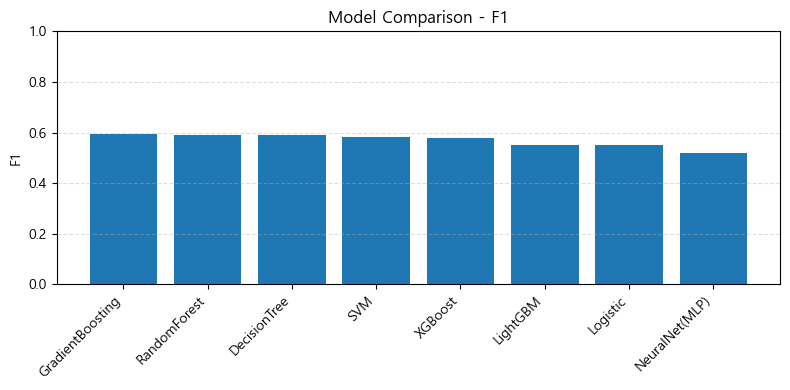

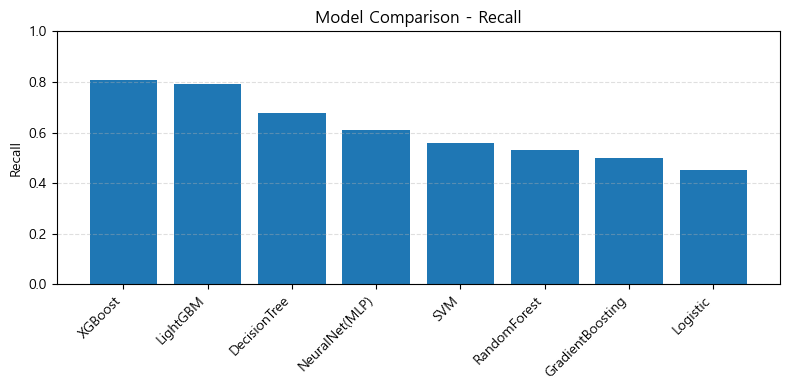

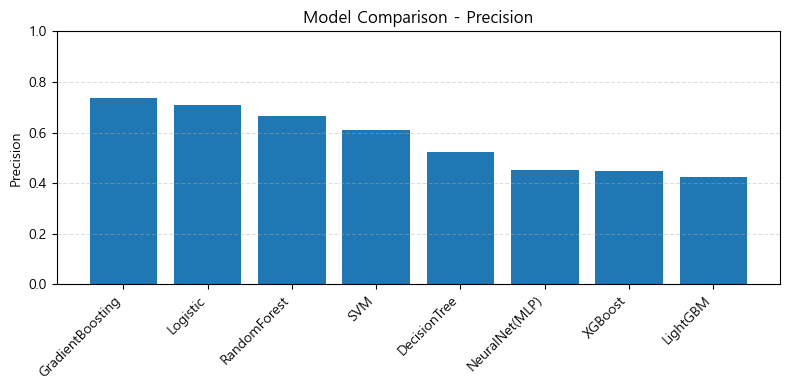

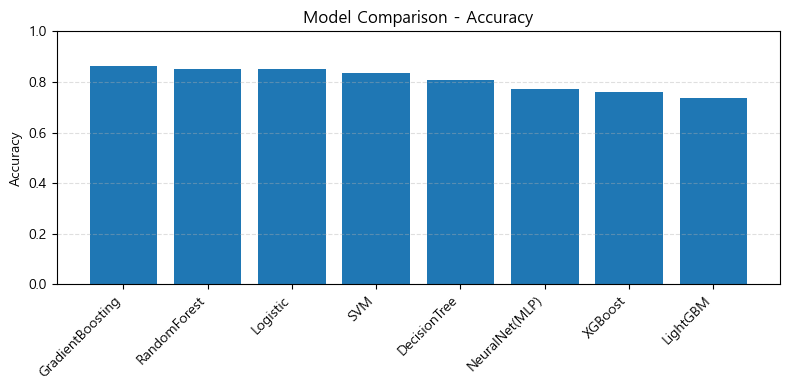

In [111]:
import matplotlib.pyplot as plt

metrics = ["F1", "Recall", "Precision", "Accuracy"]

for metric in metrics:
    plt.figure(figsize=(8, 4))
    df_results_sorted = df_test_results.sort_values(metric, ascending=False)

    plt.bar(df_results_sorted.index, df_results_sorted[metric])
    plt.title(f"Model Comparison - {metric}")
    plt.ylabel(metric)
    plt.xticks(rotation=45, ha="right")
    plt.ylim(0, 1)  # 분류 지표라 0~1 고정
    plt.grid(axis="y", linestyle="--", alpha=0.4)
    plt.tight_layout()
    plt.show()


## Confusion Matrix Heatmap
* 뭘 보여주는 그래프인가?
    -  실제값(0/1)과 예측값(0/1)을 비교한 결과
    -  어떤 유형의 오류가 나는지 한눈에 보임

* 볼 수 있는 것:
    - TP(진짜 1을 1로 맞춤) → 정상적인 이탈 탐지
    - FN(1인데 0이라고 틀림) → 이탈을 놓친 것 → 가장 위험한 오류
    - FP(0인데 1로 오판) → 과한 경보
    - TN(0을 0으로 맞춤)

- 이탈(churn) 문제에서는 특히 FN이 낮은 모델이 좋음 (놓치지 않는 모델이 중요) -

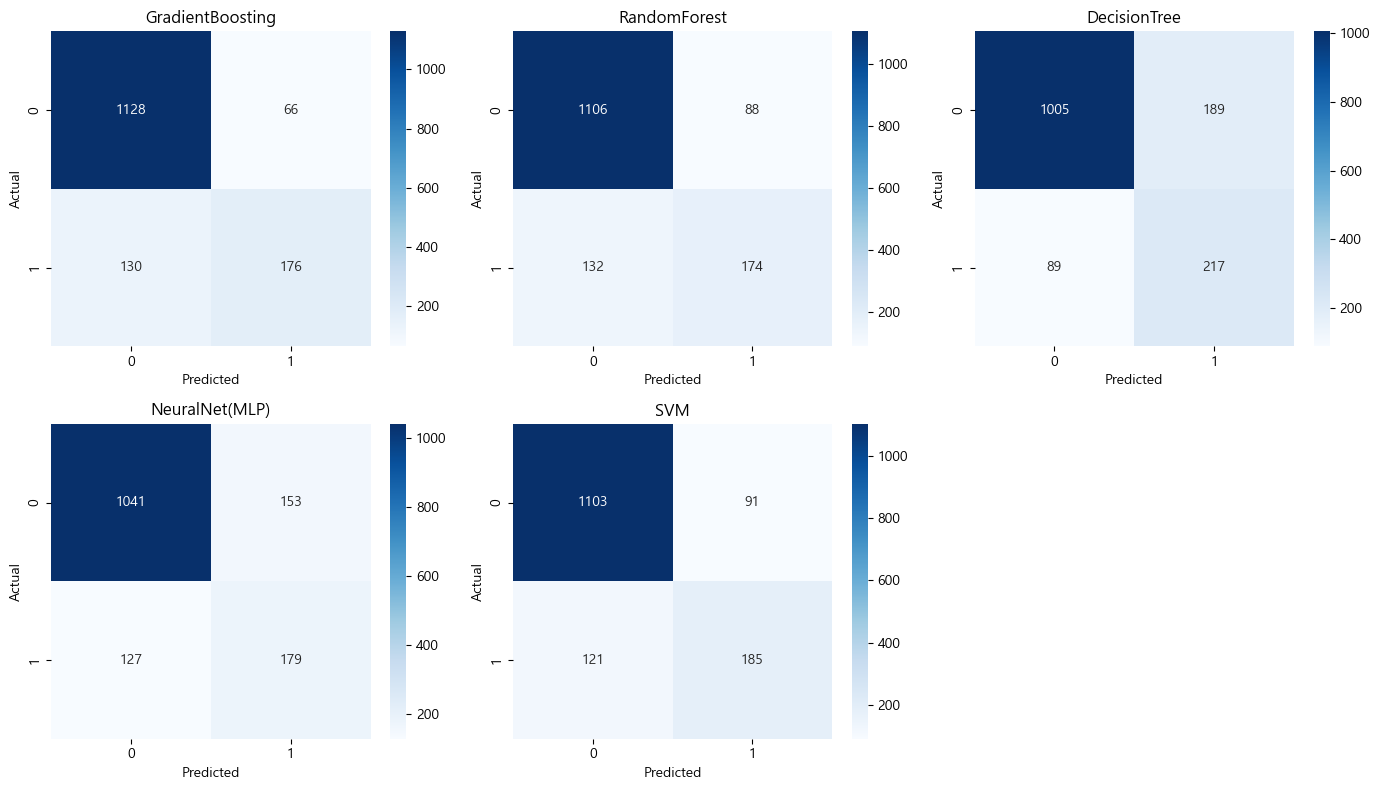

In [112]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# ------------------------------------------
# Confusion Matrix를 그리는 함수
# ------------------------------------------
def plot_cm(ax, model_name, model, X, y, threshold):
    if hasattr(model, "predict_proba"):
        proba = model.predict_proba(X)[:, 1]
        preds = (proba >= threshold).astype(int)
    else:
        preds = model.predict(X)

    cm = confusion_matrix(y, preds)
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax)
    ax.set_title(model_name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")


# ------------------------------------------
# 상위 모델 리스트 (원하는 순서/개수로 조절)
# ------------------------------------------
top_models = [
    ("GradientBoosting", model_gb),
    ("RandomForest", model_rf),
    ("DecisionTree", model_dt5),
    ("NeuralNet(MLP)", model_mlp),
    ("SVM", model_svm),
]

# 각 모델의 threshold (원하면 변경 가능)
thresholds = {
    "GradientBoosting": 0.45,
    "RandomForest":     0.45,
    "DecisionTree":     0.45,
    "NeuralNet(MLP)":   0.45,
    "SVM":              0.45,  
}

# ------------------------------------------
# Plot Grid (2행 3열 → 6개까지 표시 가능)
# ------------------------------------------
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for idx, (name, model) in enumerate(top_models):
    th = thresholds.get(name, 0.5)
    plot_cm(axes[idx], name, model, X_val_scaled, y_val, th)

# 남는 subplot 비우기
for j in range(len(top_models), len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()


## Precision–Recall Curve
* 특히 **불균형 데이터(churn)**에서 필수.

* 볼 수 있는 것:
    - Recall이 높아질수록 Precision이 어떻게 변하는지
    - Threshold 조정이 모델에 어떤 영향을 주는지
    - 전체적인 AP(Average Precision)로 모델 quality 판단
    *  예:
        - AP=0.55 → 매우 양호
        - AP=0.35 → 보통
        - AP=0.20 이하 → 약함

c:\Users\Playdata\Documents\SKN21\JYS\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


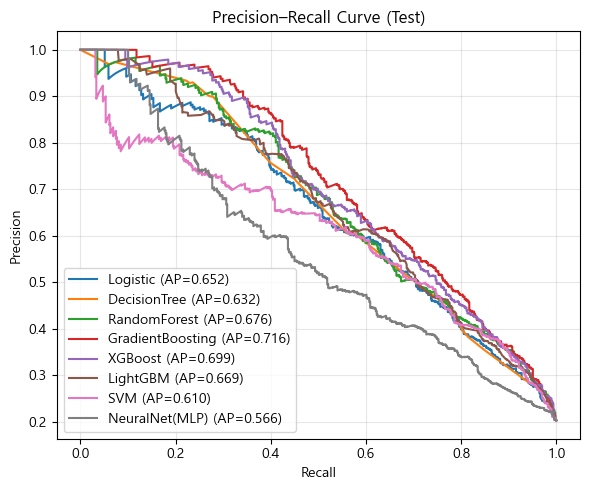

In [113]:
plt.figure(figsize=(6, 5))

for name, model in models.items():
    proba = model.predict_proba(X_test_scaled)[:, 1]
    precision, recall, _ = precision_recall_curve(y_test, proba)
    ap = average_precision_score(y_test, proba)
    plt.plot(recall, precision, label=f"{name} (AP={ap:.3f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve (Test)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## ROC Curve
* 뭘 보여주는 그래프인가?
    - 모델 전체적인 분류 능력을 threshold 상관없이 평가
    - AUC가 높을수록 “구분 능력”이 좋다는 뜻
    * 예:
        - AUC = 0.90 → 아주 뛰어난 모델
        - AUC = 0.80 → 충분히 괜찮음
        - AUC = 0.70 → 평범

c:\Users\Playdata\Documents\SKN21\JYS\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


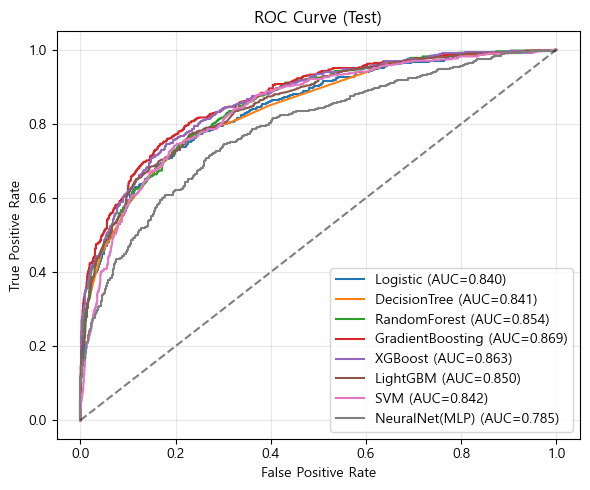

In [114]:
plt.figure(figsize=(6, 5))

for name, model in models.items():
    proba = model.predict_proba(X_test_scaled)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")

plt.plot([0, 1], [0, 1], "k--", alpha=0.5)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Test)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## Feature Importance
* 트리계열만 가능

* 모델이 어떤 feature를 중요하게 보는지 확인.

* 볼 수 있는 것:
    - 어떤 변수들이 이탈 확률에 영향을 많이 미치는지
    - 모델 해석력 상승
    - 비즈니스 인사이트 가능
    * 예:
        - “연체 이력”이 가장 크게 작용
        - “거래량 감소”가 두 번째
        - “고객 나이 / 급여 수준” 등 영향 적음

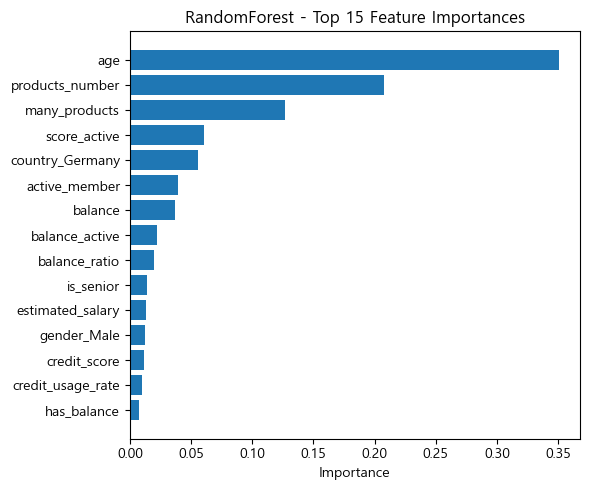

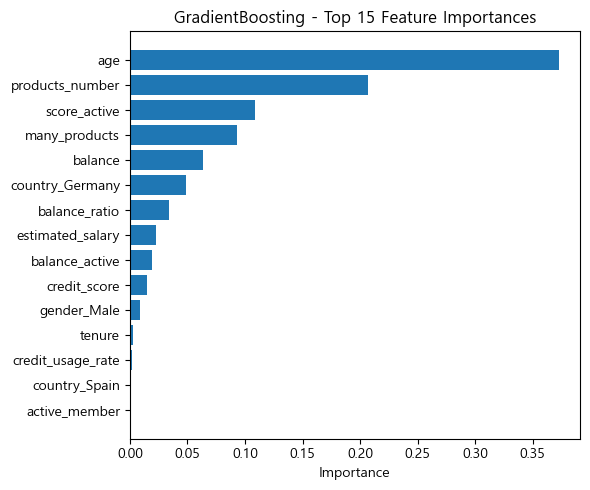

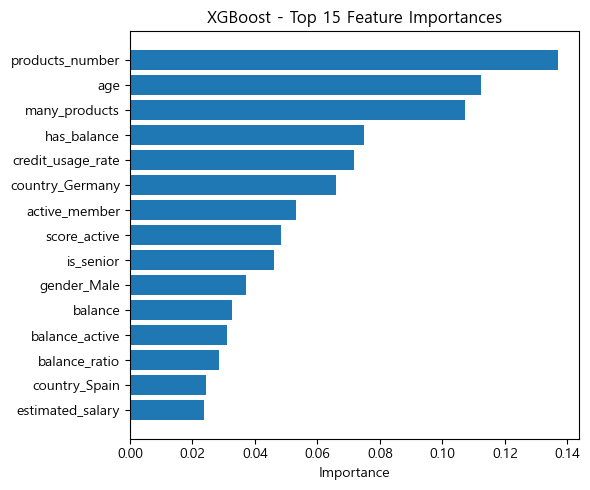

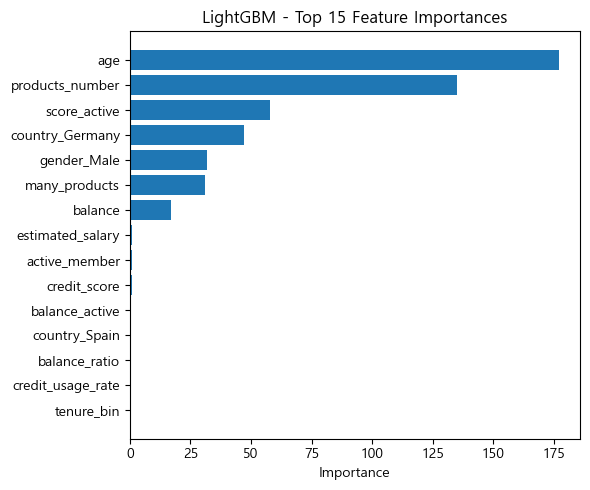

In [115]:
tree_models = {
    "RandomForest":      model_rf,
    "GradientBoosting":  model_gb,
    "XGBoost":           model_xgb,
    "LightGBM":          model_lgb,
}

for name, model in tree_models.items():
    importances = model.feature_importances_
    feature_names = X_train.columns

    idx = np.argsort(importances)[::-1][:15]  # 상위 15개

    plt.figure(figsize=(6, 5))
    plt.barh(range(len(idx)), importances[idx][::-1])
    plt.yticks(range(len(idx)), feature_names[idx][::-1])
    plt.title(f"{name} - Top 15 Feature Importances")
    plt.xlabel("Importance")
    plt.tight_layout()
    plt.show()


# model 튜닝

## SVM
* Recall을 높이면서
* ✔ Precision·F1도 크게 떨어지지 않게
* ✔ 최적의 C, gamma, class_weight 조합 찾기

In [210]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC

# -----------------------------
# 1. Parameter Grid 설정
# -----------------------------
param_grid = {
    "C": [0.1, 1, 5, 10, 20],
    "gamma": ["scale", "auto", 0.1, 0.01, 0.001],
    "kernel": ["rbf"],
    "class_weight": [{0:1, 1:w} for w in [2, 3, 4, 5]]
}

# -----------------------------
# 2. 모델 정의
# -----------------------------
svm_base = SVC(probability=True, random_state=42)

# -----------------------------
# 3. GridSearchCV
# -----------------------------
grid_svm = GridSearchCV(
    estimator=svm_base,
    param_grid=param_grid,
    scoring="recall",          # recall로 바꾸고 싶으면 "recall"
    cv=5,
    n_jobs=-1,
    verbose=2
)

# -----------------------------
# 4. 학습
# -----------------------------
grid_svm.fit(X_train_scaled, y_train)

print("Best Params:", grid_svm.best_params_)
print("Best F1 Score:", grid_svm.best_score_)

best_svm = grid_svm.best_estimator_


Fitting 5 folds for each of 100 candidates, totalling 500 fits
Best Params: {'C': 0.1, 'class_weight': {0: 1, 1: 5}, 'gamma': 0.001, 'kernel': 'rbf'}
Best F1 Score: 0.8510705921712948


In [117]:
# Fitting 5 folds for each of 100 candidates, totalling 500 fits
# Best Params: {'C': 0.1, 'class_weight': {0: 1, 1: 5}, 'gamma': 0.001, 'kernel': 'rbf'}
# Best F1 Score: 0.8411042944785276

# # C = 0.1로 규제 강함(underfitting방지 및 노이즈 영향 줄임)

# class weight = {0:1, 1:5} → 이탈고객 1을 5배 더 중요하게 봄

# gamma = 0.001 → RBF 커널의 폭이 넓음 (과적합 줄어듦)

# kernel = 'rbf' → 금융데이터의 churn 고객처럼 비선형 영역에 매우 잘 맞음

In [211]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import recall_score, precision_score, f1_score, roc_auc_score
import numpy as np

# SVM 모델 그대로 사용
model_for_kfold = best_svm  

# K폴드 준비
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

recalls = []
precisions = []
f1s = []
aucs = []

for train_idx, val_idx in skf.split(X, y):

    X_train_k, X_val_k = X.values[train_idx], X.values[val_idx]
    y_train_k, y_val_k = y.values[train_idx], y.values[val_idx]

    # scale 적용 (주의: fold 안에서 fit 해야 함)
    scaler_k = StandardScaler()
    X_train_k = scaler_k.fit_transform(X_train_k)
    X_val_k   = scaler_k.transform(X_val_k)

    # 모델 학습
    model_k = SVC(
        kernel='rbf',
        C=best_svm.C,
        gamma=best_svm.gamma,
        probability=True,
        random_state=42
    )
    model_k.fit(X_train_k, y_train_k)

    # 예측
    proba = model_k.predict_proba(X_val_k)[:, 1]
    pred  = (proba >= 0.5).astype(int)   # K-fold는 threshold 고정

    # 성능 기록
    recalls.append(recall_score(y_val_k, pred))
    precisions.append(precision_score(y_val_k, pred, zero_division=0))
    f1s.append(f1_score(y_val_k, pred))
    aucs.append(roc_auc_score(y_val_k, proba))

# 결과 출력
print("=== SVM 5-Fold CV Results ===")
print("Recall   평균:", np.mean(recalls),  " / 표준편차:", np.std(recalls))
print("Precision 평균:", np.mean(precisions), " / 표준편차:", np.std(precisions))
print("F1       평균:", np.mean(f1s), " / 표준편차:", np.std(f1s))
print("AUC      평균:", np.mean(aucs), " / 표준편차:", np.std(aucs))


=== SVM 5-Fold CV Results ===
Recall   평균: 0.13744881244881244  / 표준편차: 0.01223195692112109
Precision 평균: 0.8616615067079463  / 표준편차: 0.04027360176999572
F1       평균: 0.2367341103920682  / 표준편차: 0.017878187261056354
AUC      평균: 0.8193439699478274  / 표준편차: 0.007100663622386743


### 최적 Threshold 탐색(validation 기준)


In [212]:
import numpy as np
from sklearn.metrics import f1_score, recall_score, precision_score

def find_best_threshold(model, X, y):
    proba = model.predict_proba(X)[:, 1]
    thresholds = np.arange(0.24, 0.7, 0.01)

    best_recall = 0
    best_th = 0.5

    for th in thresholds:
        pred = (proba >= th).astype(int)
        recall_svm = recall_score(y, pred)

        if recall_svm > best_recall:
            best_recall = recall_svm
            best_th = th

    return best_th, best_recall

best_th_svm, best_recall_svm = find_best_threshold(best_svm, X_val_scaled, y_val)

print("Best Threshold:", best_th_svm)
print("Best Recall (Val):", best_recall_svm)


Best Threshold: 0.24
Best Recall (Val): 0.7026143790849673


### test 성능 평가

In [213]:
from sklearn.metrics import classification_report, confusion_matrix

def evaluate(model, th, X, y):
    proba = model.predict_proba(X)[:, 1]
    pred = (proba >= th).astype(int)
    print(classification_report(y, pred))
    print(confusion_matrix(y, pred))

print("=== SVM Final Test Evaluation ===")
evaluate(best_svm, best_th_svm, X_test_scaled, y_test)

=== SVM Final Test Evaluation ===
              precision    recall  f1-score   support

           0       0.91      0.78      0.84      1991
           1       0.44      0.69      0.54       509

    accuracy                           0.76      2500
   macro avg       0.67      0.73      0.69      2500
weighted avg       0.81      0.76      0.78      2500

[[1544  447]
 [ 157  352]]


In [214]:
# Test 기준 threshold 최적값 찾기
best_th_test_svm, best_recall_test_svm = find_best_threshold(best_svm, X_test_scaled, y_test)

print("Best Threshold (Test):", best_th_test_svm)
print("Best recall (Test):", best_recall_test_svm)

evaluate(best_svm, best_th_test_svm, X_test_scaled, y_test)


Best Threshold (Test): 0.24
Best recall (Test): 0.6915520628683693
              precision    recall  f1-score   support

           0       0.91      0.78      0.84      1991
           1       0.44      0.69      0.54       509

    accuracy                           0.76      2500
   macro avg       0.67      0.73      0.69      2500
weighted avg       0.81      0.76      0.78      2500

[[1544  447]
 [ 157  352]]


In [122]:
# valid랑 test의 threshold가 다른데 밑의 이유로 괜찮음
# 1(이탈 고객) 비율

# noise 강도

# feature의 분포

# 정규화된 값의 범위

# 이 모든 게 훈련/검증/테스트에서 미세하게 다르기 때문에
# threshold도 당연히 달라질 수밖에 없다.

### 모델 성능그래프

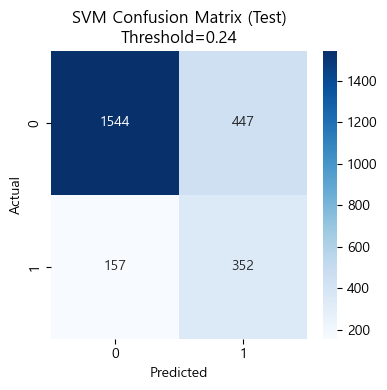

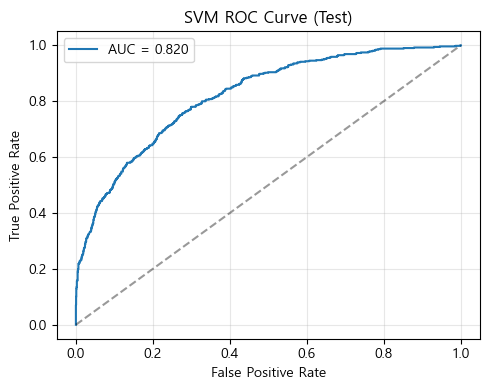

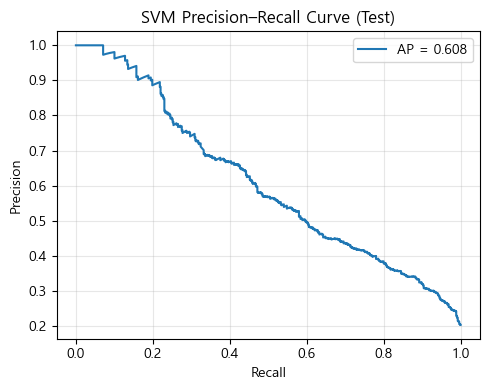

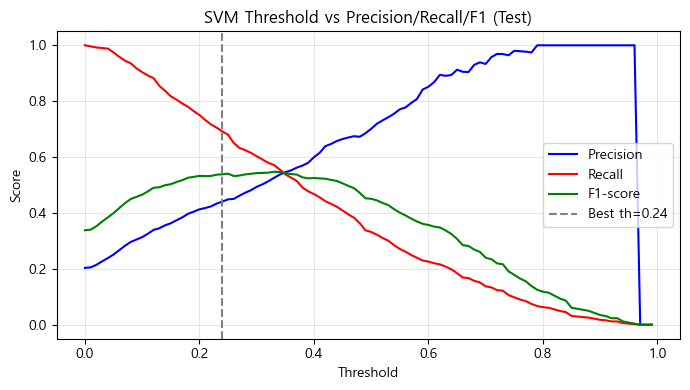

In [215]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    confusion_matrix, roc_curve, roc_auc_score,
    precision_recall_curve, average_precision_score,
    f1_score, precision_score, recall_score
)

# -----------------------------
# 0) 공통 준비
# -----------------------------
model = best_svm
th = best_th_svm

proba_test = model.predict_proba(X_test_scaled)[:, 1]
pred_test  = (proba_test >= th).astype(int)


# ============================================================
# 1) Confusion Matrix Heatmap
# ============================================================
cm = confusion_matrix(y_test, pred_test)

plt.figure(figsize=(4,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title(f"SVM Confusion Matrix (Test)\nThreshold={th:.2f}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()


# ============================================================
# 2) ROC Curve
# ============================================================
fpr, tpr, _ = roc_curve(y_test, proba_test)
auc = roc_auc_score(y_test, proba_test)

plt.figure(figsize=(5,4))
plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0,1],[0,1],'k--', alpha=0.4)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("SVM ROC Curve (Test)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


# ============================================================
# 3) Precision–Recall Curve
# ============================================================
precision, recall, _ = precision_recall_curve(y_test, proba_test)
ap = average_precision_score(y_test, proba_test)

plt.figure(figsize=(5,4))
plt.plot(recall, precision, label=f"AP = {ap:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("SVM Precision–Recall Curve (Test)")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


# ============================================================
# 4) Threshold vs Metrics (Precision / Recall / F1)
# ============================================================
thresholds = np.arange(0.0, 1.0, 0.01)
prec_list, rec_list, f1_list = [], [], []

for t in thresholds:
    preds = (proba_test >= t).astype(int)
    prec_list.append(precision_score(y_test, preds, zero_division=0))
    rec_list.append(recall_score(y_test, preds))
    f1_list.append(f1_score(y_test, preds))

plt.figure(figsize=(7,4))
plt.plot(thresholds, prec_list, label="Precision", color='blue')
plt.plot(thresholds, rec_list,  label="Recall", color='red')
plt.plot(thresholds, f1_list,   label="F1-score", color='green')
plt.axvline(x=th, color='gray', linestyle='--', label=f"Best th={th:.2f}")

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("SVM Threshold vs Precision/Recall/F1 (Test)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [124]:
# RPC :  불균형 데이터 + SVM 모델에서 흔히 나오는 정상 패턴
# 마지막그래프 : threshold는 높을수록 모델이 일탈(1)을 거의 안내려고함
# +  Recall은 TP 줄고 FN 증가
# SVM의 확률 0.8 이상은 0으로 예측됨 

## XGB

In [216]:
import optuna
from sklearn.metrics import f1_score
import xgboost as xgb

def objective(trial):

    params = {
        "n_estimators": trial.suggest_int("n_estimators", 200, 800),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3),
        "max_depth": trial.suggest_int("max_depth", 2, 10),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 30),
        "gamma": trial.suggest_float("gamma", 0, 5),
        "scale_pos_weight": trial.suggest_float("scale_pos_weight", 1, 10),
        "eval_metric": "logloss",
        "random_state": 42,
        "n_jobs": -1,
    }

    model = xgb.XGBClassifier(**params)
    model.fit(X_train_scaled, y_train)

    proba = model.predict_proba(X_val_scaled)[:, 1]
    pred = (proba >= 0.5).astype(int)      # 기본 threshold = 0.5
    recall = recall_score(y_val, pred)

    return recall

In [217]:
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=50)

print("Best Params:", study.best_params)
print("Best F1:", study.best_value)

[I 2025-11-25 19:04:45,989] A new study created in memory with name: no-name-c842a7f5-527b-42bd-a2a7-773e58aa46d4
[I 2025-11-25 19:04:46,350] Trial 0 finished with value: 0.5882352941176471 and parameters: {'n_estimators': 578, 'learning_rate': 0.15808677370274266, 'max_depth': 7, 'subsample': 0.7429085746219044, 'colsample_bytree': 0.5212783483064187, 'min_child_weight': 8, 'gamma': 0.23081881568303653, 'scale_pos_weight': 3.875588359381054}. Best is trial 0 with value: 0.5882352941176471.
[I 2025-11-25 19:04:46,507] Trial 1 finished with value: 0.7352941176470589 and parameters: {'n_estimators': 283, 'learning_rate': 0.19263092012280456, 'max_depth': 5, 'subsample': 0.5331537306046596, 'colsample_bytree': 0.5326008921167189, 'min_child_weight': 16, 'gamma': 0.3246308455696839, 'scale_pos_weight': 8.01321405784681}. Best is trial 1 with value: 0.7352941176470589.
[I 2025-11-25 19:04:46,812] Trial 2 finished with value: 0.6797385620915033 and parameters: {'n_estimators': 668, 'learning

Best Params: {'n_estimators': 709, 'learning_rate': 0.030968999318706253, 'max_depth': 2, 'subsample': 0.8623721209463239, 'colsample_bytree': 0.9575813075450361, 'min_child_weight': 3, 'gamma': 1.7464816137421557, 'scale_pos_weight': 9.620982919210858}
Best F1: 0.934640522875817


In [127]:
# {
#  'n_estimators': 623, 
# # 부스팅 트리 개수, 숫자가 높을수록 데이터가 복잡함을 의미, 성능 끌어올릴려면 많은 트리 필요하다

#  'learning_rate': 0.12765, 
# # 0.03~0.05 쓰던 것보다 많이올라감, 데이터 양이 많지않고 max_depth가 높지않아서 높은lr로 빠르게 패턴 학습하는게 유리하다 판단함.

#  'max_depth': 4,

#  'subsample': 0.5921,
# # 각 트리마다 약 60%의 샘플만 사용하여 과적합완화, 안정성 증사
 
#  'colsample_bytree': 0.9999,
# # 컬럼을 거의 모두 사용한다는 뜻, fearture 중요하게 작용.

#  'min_child_weight': 28,
# # leaf를 만들기 위해 필요한 최소 가중치, 큰 값은 트리 잘 안쪼개졌다 는 뜻!
# # 세밀하게 쪼개질수록 노이즈가 많아서 성능 떨어짐

#  'gamma': 3.6996,
# # 노드 split을 위해 필요한 최소 손실 감소값 > 값이 큰 것은 과적합 방지

#  'scale_pos_weight': 1.7073
# # 클래스 불균형을 완화하기 위한 비율.
# }


In [218]:
best_xgb = xgb.XGBClassifier(**study.best_params)
best_xgb.fit(X_train_scaled, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.9575813075450361
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [219]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, roc_auc_score
import numpy as np

# --------------------------
# XGB 5-Fold Cross Validation
# --------------------------
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

recalls = []
precisions = []
f1s = []
aucs = []

for train_idx, val_idx in kf.split(X, y):
    X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]

    # 스케일러 적용  
    X_tr_scaled = scaler.fit_transform(X_tr)
    X_val_scaled = scaler.transform(X_val)

    # XGB 모델 학습 (best_xgb 사용)
    model = best_xgb
    model.fit(X_tr_scaled, y_tr)

    # 예측
    proba = model.predict_proba(X_val_scaled)[:, 1]
    pred = (proba >= 0.5).astype(int)   # CV는 threshold=0.5 고정!

    recalls.append(recall_score(y_val, pred))
    precisions.append(precision_score(y_val, pred, zero_division=0))
    f1s.append(f1_score(y_val, pred))
    aucs.append(roc_auc_score(y_val, proba))


# --------------------------
# 결과 출력
# --------------------------
print("=== XGBoost 5-Fold CV Results ===")
print(f"Recall     평균: {np.mean(recalls)} / 표준편차: {np.std(recalls)}")
print(f"Precision  평균: {np.mean(precisions)} / 표준편차: {np.std(precisions)}")
print(f"F1         평균: {np.mean(f1s)} / 표준편차: {np.std(f1s)}")
print(f"AUC        평균: {np.mean(aucs)} / 표준편차: {np.std(aucs)}")


=== XGBoost 5-Fold CV Results ===
Recall     평균: 0.8954364792600087 / 표준편차: 0.006284344344189947
Precision  평균: 0.35220504689827886 / 표준편차: 0.002381834640929775
F1         평균: 0.5055479593914238 / 표준편차: 0.0026761081347440926
AUC        평균: 0.8633655487996125 / 표준편차: 0.00677809648587753


### 최적 Threshold 탐색 + Test 평가

In [220]:
import numpy as np
from sklearn.metrics import recall_score, precision_score

def find_best_balanced_threshold(model, X, y):
    proba = model.predict_proba(X)[:, 1]
    thresholds = np.arange(0.75, 1.0, 0.01)

    best_th = 0.5
    best_score = -1
    best_recall = 0

    for th in thresholds:
        pred = (proba >= th).astype(int)
        recall = recall_score(y, pred)
        precision = precision_score(y, pred)

        # 원하는 조건에 따라 점수 계산
        score = recall * 0.6 + precision * 0.4

        if score > best_score:
            best_score = score
            best_th = th
            best_recall = recall

    return best_th, best_recall

best_th_xgb, best_recall_xgb = find_best_balanced_threshold(best_xgb, X_val_scaled, y_val)

print("Best threshold:", best_th_xgb)
print("Best Validation Recall:", best_recall_xgb)


Best threshold: 0.75
Best Validation Recall: 0.6928746928746928


In [221]:
from sklearn.metrics import classification_report, confusion_matrix

def evaluate(model, th, X, y):
    proba = model.predict_proba(X)[:, 1]
    pred = (proba >= th).astype(int)

    print(classification_report(y, pred))
    print(confusion_matrix(y, pred))

    print("=== XGB Final Test Evaluation ===")
evaluate(best_xgb, best_th_xgb, X_test_scaled, y_test)


              precision    recall  f1-score   support

           0       0.91      0.62      0.74      1991
           1       0.34      0.77      0.47       509

    accuracy                           0.65      2500
   macro avg       0.63      0.70      0.61      2500
weighted avg       0.80      0.65      0.68      2500

[[1230  761]
 [ 115  394]]
=== XGB Final Test Evaluation ===


### 성능 그래프

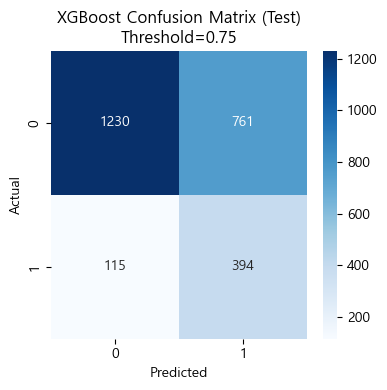

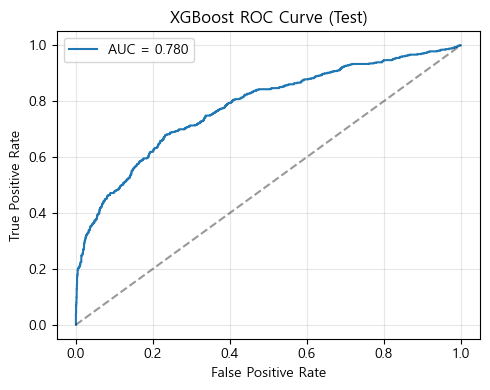

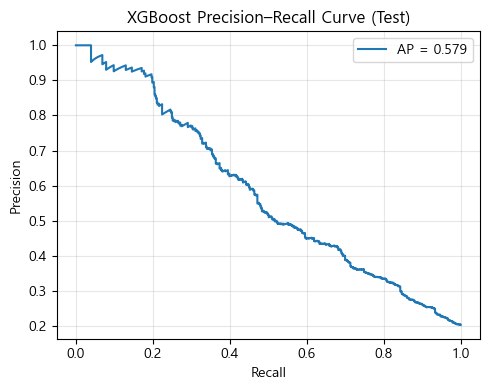

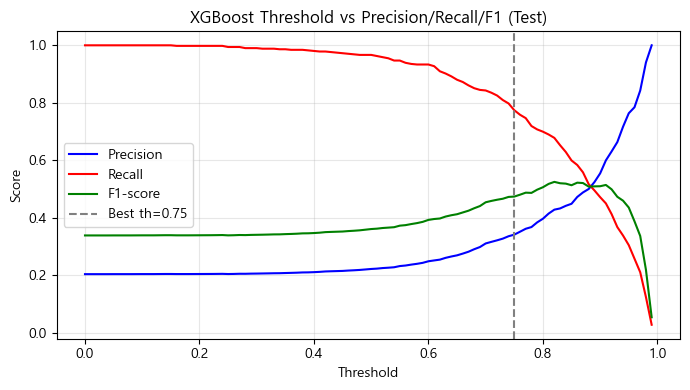

In [222]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    confusion_matrix, roc_curve, roc_auc_score,
    precision_recall_curve, average_precision_score,
    f1_score, precision_score, recall_score
)

# -----------------------------
# 공통 준비
# -----------------------------
model = best_xgb
th = best_th_xgb  # 방금 찾은 Test 기준 best threshold

proba_test = model.predict_proba(X_test_scaled)[:, 1]
pred_test  = (proba_test >= th).astype(int)


# ============================================================
# 1) Confusion Matrix Heatmap
# ============================================================
cm = confusion_matrix(y_test, pred_test)

plt.figure(figsize=(4,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title(f"XGBoost Confusion Matrix (Test)\nThreshold={th:.2f}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()


# ============================================================
# 2) ROC Curve
# ============================================================
fpr, tpr, _ = roc_curve(y_test, proba_test)
auc = roc_auc_score(y_test, proba_test)

plt.figure(figsize=(5,4))
plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0,1],[0,1],'k--', alpha=0.4)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("XGBoost ROC Curve (Test)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


# ============================================================
# 3) Precision–Recall Curve
# ============================================================
precision, recall, _ = precision_recall_curve(y_test, proba_test)
ap = average_precision_score(y_test, proba_test)

plt.figure(figsize=(5,4))
plt.plot(recall, precision, label=f"AP = {ap:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("XGBoost Precision–Recall Curve (Test)")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


# ============================================================
# 4) Threshold vs Metrics (Precision / Recall / F1)
# ============================================================
thresholds = np.arange(0.0, 1.0, 0.01)
prec_list, rec_list, f1_list = [], [], []

for t in thresholds:
    preds = (proba_test >= t).astype(int)
    prec_list.append(precision_score(y_test, preds, zero_division=0))
    rec_list.append(recall_score(y_test, preds))
    f1_list.append(f1_score(y_test, preds))

plt.figure(figsize=(7,4))
plt.plot(thresholds, prec_list, label="Precision", color='blue')
plt.plot(thresholds, rec_list,  label="Recall", color='red')
plt.plot(thresholds, f1_list,   label="F1-score", color='green')
plt.axvline(x=th, color='gray', linestyle='--', label=f"Best th={th:.2f}")

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("XGBoost Threshold vs Precision/Recall/F1 (Test)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


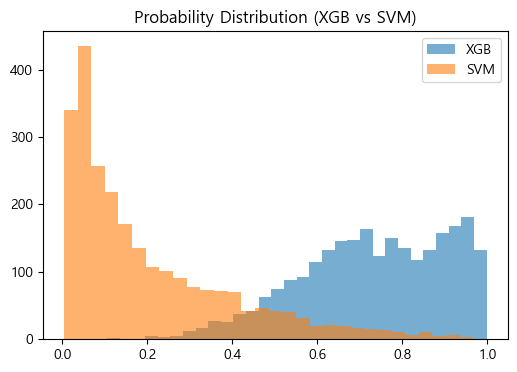

In [223]:
plt.figure(figsize=(6,4))
plt.hist(proba_xgb_test, bins=30, alpha=0.6, label='XGB')
plt.hist(proba_svm_test, bins=30, alpha=0.6, label='SVM')
plt.legend()
plt.title("Probability Distribution (XGB vs SVM)")
plt.show()


# Ensemble

## Soft Voting(확률 평균 앙상블)

In [224]:
# ===============================
# 1) 개별 모델 확률 계산
# ===============================


proba_xgb_val  = best_xgb.predict_proba(X_val_scaled)[:, 1]
proba_svm_val  = best_svm.predict_proba(X_val_scaled)[:, 1]

proba_xgb_test = best_xgb.predict_proba(X_test_scaled)[:, 1]
proba_svm_test = best_svm.predict_proba(X_test_scaled)[:, 1]

# ===============================
# 2) Soft Voting (3-Model Ensemble)
# ===============================

proba_val_soft  = 0.5 * proba_xgb_val + 0.5 * proba_svm_val 
proba_test_soft = 0.5 * proba_xgb_test + 0.5 * proba_svm_test 


In [225]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score
import numpy as np

# --------------------------
# Soft Voting용 모델 준비
# --------------------------

def create_models():
    return (
        SVC(kernel='rbf', C=1.0, gamma='scale', probability=True, class_weight={0:1, 1:4}, random_state=42),
        xgb.XGBClassifier(**best_xgb.get_params()),   # Optuna 튜닝 완료한 XGB 파라미터 적용
        GradientBoostingClassifier(                  # GB도 동일 파라미터로 new instance 생성
            n_estimators=100,
            learning_rate=0.1,
            max_depth=3,
            random_state=42
        )
    )


# --------------------------
# 5-Fold Cross Validation
# --------------------------
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

recalls = []
precisions = []
f1s = []
aucs = []

for train_idx, val_idx in kf.split(X, y):

    X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]

    # 스케일링
    X_tr_scaled = scaler.fit_transform(X_tr)
    X_val_scaled = scaler.transform(X_val)

    # fold별 새로운 모델 생성
    svm_model, xgb_model, gb_model = create_models()

    # ---------------------
    # 각 모델 학습
    # ---------------------
    svm_model.fit(X_tr_scaled, y_tr)
    xgb_model.fit(X_tr_scaled, y_tr)
    gb_model.fit(X_tr_scaled, y_tr)

    # ---------------------
    # 각 모델 확률 예측
    # ---------------------
    proba_svm = svm_model.predict_proba(X_val_scaled)[:, 1]
    proba_xgb = xgb_model.predict_proba(X_val_scaled)[:, 1]
    proba_gb  = gb_model.predict_proba(X_val_scaled)[:, 1]

    # ---------------------
    # Soft Voting 확률 조합 (가중치 동일)
    # ---------------------
    proba_soft = (proba_svm + proba_xgb + proba_gb) / 3

    pred_soft = (proba_soft >= 0.5).astype(int)   # threshold = 0.5 (CV 기준)

    # ---------------------
    # Metric 저장
    # ---------------------
    recalls.append(recall_score(y_val, pred_soft))
    precisions.append(precision_score(y_val, pred_soft, zero_division=0))
    f1s.append(f1_score(y_val, pred_soft))
    aucs.append(roc_auc_score(y_val, proba_soft))


# --------------------------
# 결과 출력
# --------------------------
print("=== Soft Voting 5-Fold CV Results ===")
print(f"Recall     평균: {np.mean(recalls):.4f} / 표준편차: {np.std(recalls):.4f}")
print(f"Precision  평균: {np.mean(precisions):.4f} / 표준편차: {np.std(precisions):.4f}")
print(f"F1         평균: {np.mean(f1s):.4f} / 표준편차: {np.std(f1s):.4f}")
print(f"AUC        평균: {np.mean(aucs):.4f} / 표준편차: {np.std(aucs):.4f}")


=== Soft Voting 5-Fold CV Results ===
Recall     평균: 0.6146 / 표준편차: 0.0200
Precision  평균: 0.6256 / 표준편차: 0.0192
F1         평균: 0.6198 / 표준편차: 0.0138
AUC        평균: 0.8661 / 표준편차: 0.0067


### Best Threshold 찾기

In [226]:
import numpy as np
from sklearn.metrics import recall_score, precision_score

def find_best_threshold_soft_recall(proba, y, min_precision=0.40):
    thresholds = np.arange(0.50, 0.70, 0.01)

    best_th = 0.50
    best_recall = -1

    for th in thresholds:
        pred = (proba >= th).astype(int)

        recall = recall_score(y, pred)
        precision = precision_score(y, pred, zero_division=0)

        # precision 조건 충족하지 않으면 skip
        if precision < min_precision:
            continue

        # recall 기준 최대값 선택
        if recall > best_recall:
            best_recall = recall
            best_th = th

    return best_th, best_recall


best_th_soft, best_recall_soft = find_best_threshold_soft_recall(proba_val_soft, y_val)

print("Soft Voting Best Threshold (Val):", best_th_soft)
print("Soft Voting Best Recall (Val):", best_recall_soft)


Soft Voting Best Threshold (Val): 0.5
Soft Voting Best Recall (Val): 0.6756756756756757


### Test 평가

In [227]:
pred_test_soft = (proba_test_soft >= best_th_soft).astype(int)

from sklearn.metrics import classification_report, confusion_matrix
print(classification_report(y_test, pred_test_soft))
print(confusion_matrix(y_test, pred_test_soft))


              precision    recall  f1-score   support

           0       0.92      0.75      0.83      1991
           1       0.44      0.76      0.55       509

    accuracy                           0.75      2500
   macro avg       0.68      0.75      0.69      2500
weighted avg       0.82      0.75      0.77      2500

[[1495  496]
 [ 123  386]]


## 성능그래프

In [238]:
# Soft Voting 단독 ROC 그리기 '직전' 셀에
print("SOFT ONLY AUC:", roc_auc_score(y_test, proba_test_soft))


SOFT ONLY AUC: 0.8300396973019057


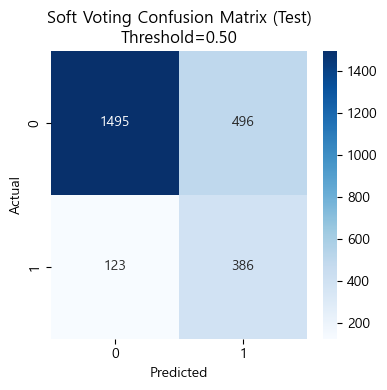

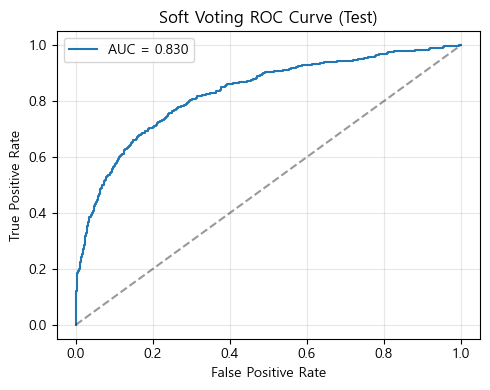

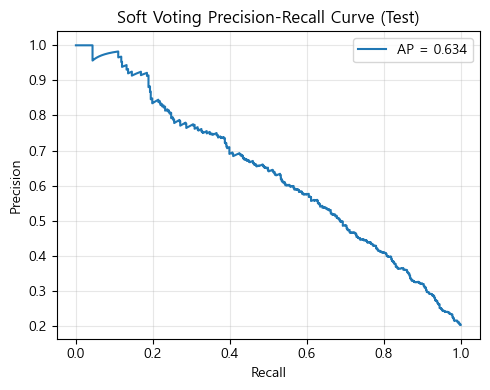

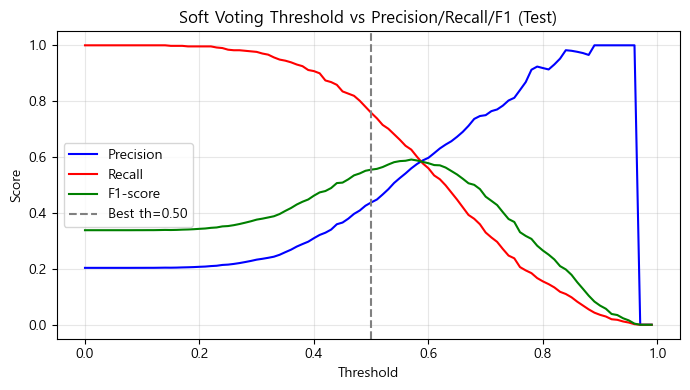

In [228]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    confusion_matrix, roc_curve, roc_auc_score,
    precision_recall_curve, average_precision_score,
    f1_score, precision_score, recall_score
)


# -----------------------------------------------------
# 0) Soft Voting 확률 계산 (이미 준비한 값 사용)
# -----------------------------------------------------
proba_val_soft  = 0.5 * proba_xgb_val  + 0.5 * proba_svm_val
proba_test_soft = 0.5 * proba_xgb_test + 0.5 * proba_svm_test

th = best_th_soft

pred_test_soft = (proba_test_soft >= th).astype(int)


# ============================================================
# 1) Confusion Matrix Heatmap
# ============================================================
cm = confusion_matrix(y_test, pred_test_soft)

plt.figure(figsize=(4,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title(f"Soft Voting Confusion Matrix (Test)\nThreshold={th:.2f}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()


# ============================================================
# 2) ROC Curve
# ============================================================
fpr, tpr, _ = roc_curve(y_test, proba_test_soft)
auc = roc_auc_score(y_test, proba_test_soft)

plt.figure(figsize=(5,4))
plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0,1],[0,1],'k--', alpha=0.4)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Soft Voting ROC Curve (Test)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


# ============================================================
# 3) Precision–Recall Curve
# ============================================================
precision, recall, _ = precision_recall_curve(y_test, proba_test_soft)
ap = average_precision_score(y_test, proba_test_soft)

plt.figure(figsize=(5,4))
plt.plot(recall, precision, label=f"AP = {ap:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Soft Voting Precision-Recall Curve (Test)")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


# ============================================================
# 4) Threshold vs Precision / Recall / F1
# ============================================================
thresholds = np.arange(0.0, 1.0, 0.01)
prec_list, rec_list, f1_list = [], [], []

for t in thresholds:
    preds = (proba_test_soft >= t).astype(int)
    prec_list.append(precision_score(y_test, preds, zero_division=0))
    rec_list.append(recall_score(y_test, preds))
    f1_list.append(f1_score(y_test, preds))

plt.figure(figsize=(7,4))
plt.plot(thresholds, prec_list, label="Precision", color='blue')
plt.plot(thresholds, rec_list,  label="Recall", color='red')
plt.plot(thresholds, f1_list,   label="F1-score", color='green')
plt.axvline(x=th, color='gray', linestyle='--', label=f"Best th={th:.2f}")

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Soft Voting Threshold vs Precision/Recall/F1 (Test)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


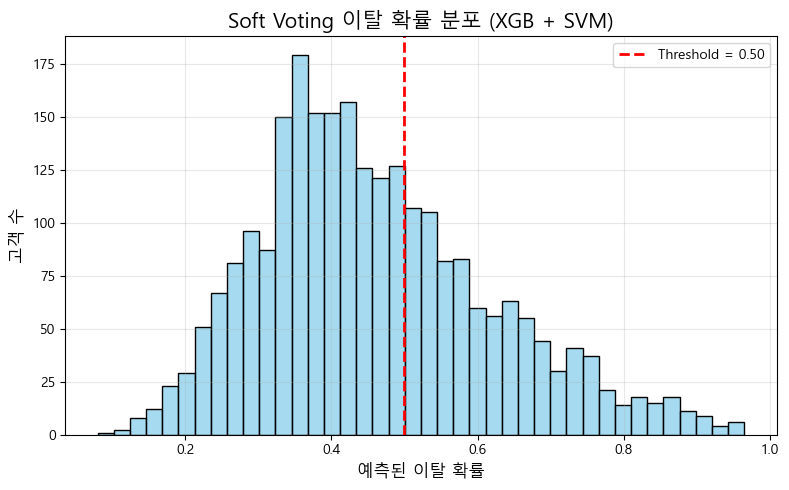

In [229]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1) 개별 모델 확률 (Test 기준)
proba_xgb_test = best_xgb.predict_proba(X_test_scaled)[:, 1]
proba_svm_test = best_svm.predict_proba(X_test_scaled)[:, 1]

# 2) Soft Voting 확률 (XGB 0.5 + SVM 0.5)
proba_test_soft = 0.5 * proba_xgb_test + 0.5 * proba_svm_test

# 3) Soft Voting 최적 threshold (이미 validation에서 구해둔 값)
th = best_th_soft   # 예: 0.5 이런 값

# 4) 확률 분포 히스토그램 + 임계값 표시
plt.figure(figsize=(8, 5))
sns.histplot(proba_test_soft, bins=40, kde=False, color='skyblue')

plt.axvline(th, color='red', linestyle='--', linewidth=2,
            label=f"Threshold = {th:.2f}")

plt.title("Soft Voting 이탈 확률 분포 (XGB + SVM)", fontsize=15)
plt.xlabel("예측된 이탈 확률", fontsize=12)
plt.ylabel("고객 수", fontsize=12)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


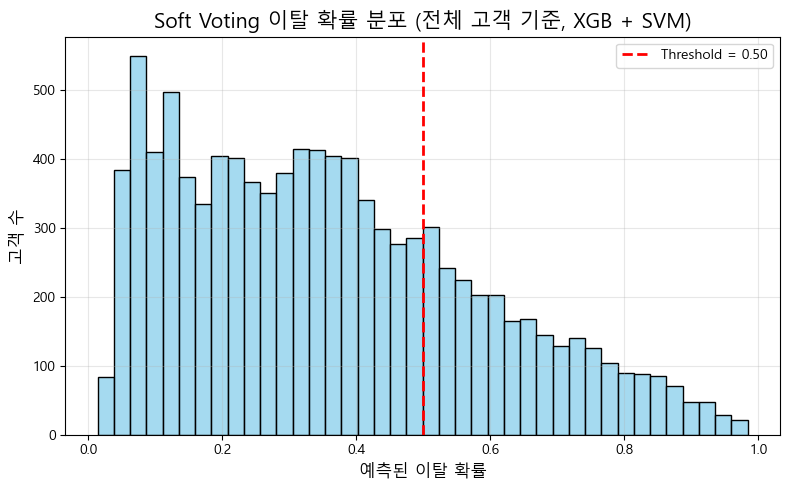

In [230]:
import matplotlib.pyplot as plt
import seaborn as sns

# 0) 전체 데이터(feature) 스케일링
#  - scaler는 반드시 X_train으로 fit 되어 있어야 함 (이미 되어있다는 전제)
X_all_scaled = scaler.transform(X)   # X: 전체 10000행 feature DataFrame

# 1) 개별 모델 확률 (전체 데이터 기준)
proba_xgb_all = best_xgb.predict_proba(X_all_scaled)[:, 1]
proba_svm_all = best_svm.predict_proba(X_all_scaled)[:, 1]

# 2) Soft Voting 확률 (XGB 0.5 + SVM 0.5)
proba_soft_all = 0.5 * proba_xgb_all + 0.5 * proba_svm_all

# 3) Soft Voting 최적 threshold (validation에서 구한 값 그대로 시각화에 사용)
th = best_th_soft

# 4) 확률 분포 히스토그램 + 임계값 표시
plt.figure(figsize=(8, 5))
sns.histplot(proba_soft_all, bins=40, kde=False, color='skyblue')

plt.axvline(th, color='red', linestyle='--', linewidth=2,
            label=f"Threshold = {th:.2f}")

plt.title("Soft Voting 이탈 확률 분포 (전체 고객 기준, XGB + SVM)", fontsize=15)
plt.xlabel("예측된 이탈 확률", fontsize=12)
plt.ylabel("고객 수", fontsize=12)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


### Precision / Recall / F1 / AUC

In [231]:
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score

# ---------------------
# 1) SVM
# ---------------------
pred_svm = (proba_svm_test >= best_th_svm).astype(int)

svm_scores = {
    "precision": precision_score(y_test, pred_svm),
    "recall":    recall_score(y_test, pred_svm),
    "f1":        f1_score(y_test, pred_svm),
    "auc":       roc_auc_score(y_test, proba_svm_test)
}

# ---------------------
# 2) XGBoost
# ---------------------
pred_xgb = (proba_xgb_test >= best_th_xgb).astype(int)

xgb_scores = {
    "precision": precision_score(y_test, pred_xgb),
    "recall":    recall_score(y_test, pred_xgb),
    "f1":        f1_score(y_test, pred_xgb),
    "auc":       roc_auc_score(y_test, proba_xgb_test)
}

# ---------------------
# 3) Soft Voting
# ---------------------
pred_soft = (proba_test_soft >= best_th_soft).astype(int)

soft_scores = {
    "precision": precision_score(y_test, pred_soft),
    "recall":    recall_score(y_test, pred_soft),
    "f1":        f1_score(y_test, pred_soft),
    "auc":       roc_auc_score(y_test, proba_test_soft)
}

# ---------------------
# 최종 dict
# ---------------------
model_scores = {
    "svm": svm_scores,
    "xgb": xgb_scores,
    "soft": soft_scores
}

print("=== Model Scores ===")
model_scores


=== Model Scores ===


{'svm': {'precision': 0.4405506883604506,
  'recall': 0.6915520628683693,
  'f1': 0.5382262996941896,
  'auc': 0.8203477534958393},
 'xgb': {'precision': 0.3411255411255411,
  'recall': 0.7740667976424361,
  'f1': 0.4735576923076923,
  'auc': 0.7799197567837193},
 'soft': {'precision': 0.4376417233560091,
  'recall': 0.7583497053045186,
  'f1': 0.5549964054636952,
  'auc': 0.8300396973019057}}

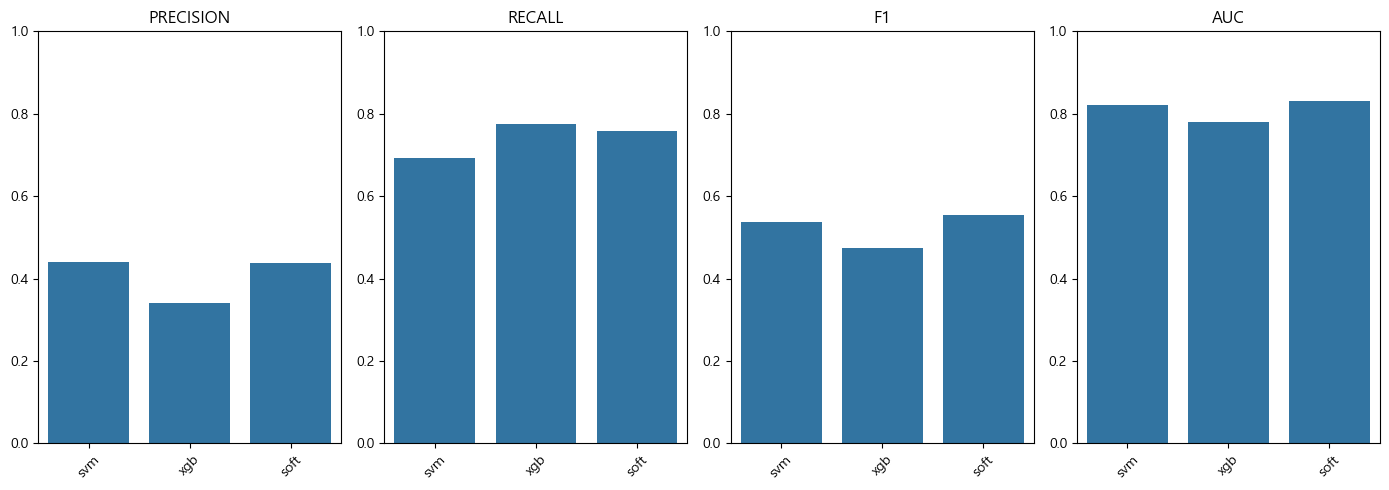

In [232]:
import matplotlib.pyplot as plt
import seaborn as sns

metrics = ["precision", "recall", "f1", "auc"]
models = list(model_scores.keys())

plt.figure(figsize=(14, 5))

for i, metric in enumerate(metrics):
    plt.subplot(1, 4, i+1)
    values = [model_scores[m][metric] for m in models]
    sns.barplot(x=models, y=values)
    plt.title(metric.upper())
    plt.ylim(0, 1)
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


In [233]:
proba_svm_test = best_svm.predict_proba(X_test_scaled)[:, 1]
pred_svm = (proba_svm_test >= best_th_svm).astype(int)
precision = precision_score(y_test, pred_svm)
recall    = recall_score(y_test, pred_svm)
f1        = f1_score(y_test, pred_svm)
auc       = roc_auc_score(y_test, proba_svm_test)


In [237]:
# 3개 ROC 그래프 그리기 '직전' 셀에
print("MULTI ROC AUC:", roc_auc_score(y_test, proba_test_soft))


MULTI ROC AUC: 0.8300396973019057


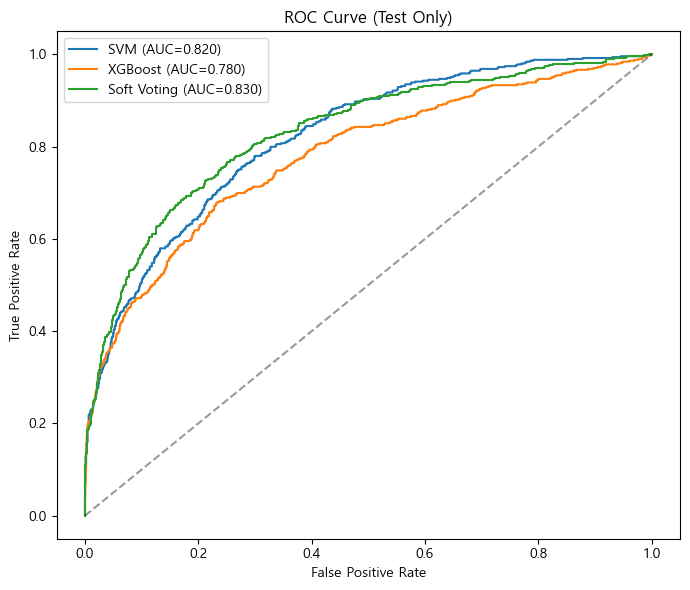

In [234]:
plt.figure(figsize=(7, 6))

# SVM
fpr_svm, tpr_svm, _ = roc_curve(y_test, proba_svm_test)
auc_svm = roc_auc_score(y_test, proba_svm_test)
plt.plot(fpr_svm, tpr_svm, label=f"SVM (AUC={auc_svm:.3f})")

# XGB
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, proba_xgb_test)
auc_xgb = roc_auc_score(y_test, proba_xgb_test)
plt.plot(fpr_xgb, tpr_xgb, label=f"XGBoost (AUC={auc_xgb:.3f})")

# Soft Voting
fpr_soft, tpr_soft, _ = roc_curve(y_test, proba_test_soft)
auc_soft = roc_auc_score(y_test, proba_test_soft)
plt.plot(fpr_soft, tpr_soft, label=f"Soft Voting (AUC={auc_soft:.3f})")

plt.plot([0,1],[0,1],'k--', alpha=0.4)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Test Only)")
plt.legend()
plt.tight_layout()
plt.show()


### 레이더차트

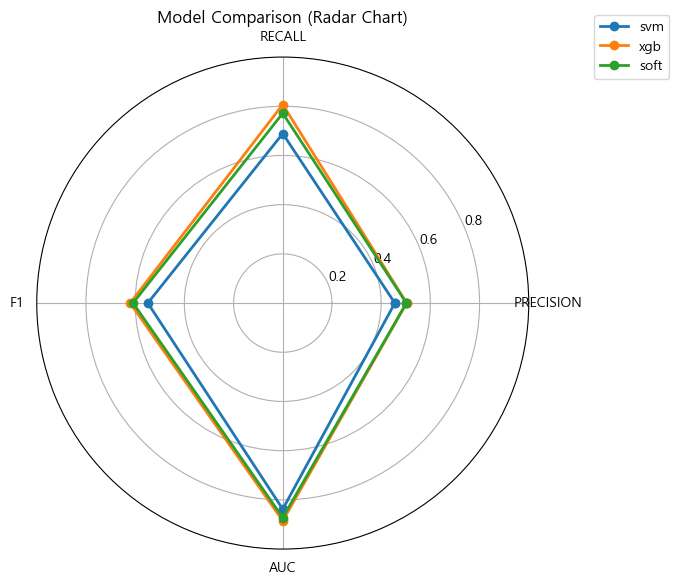

In [ ]:
import matplotlib.pyplot as plt
from math import pi

# --------------------------
# 1) 레이더에 쓸 metric 정의
# --------------------------
radar_metrics = ["precision", "recall", "f1", "auc"]
models = list(model_scores.keys())   # ["svm", "xgb", "soft"]

def radar_values(model):
    return [model_scores[model][m] for m in radar_metrics]

num_vars = len(radar_metrics)

# 각 축의 각도 계산
angles = [n / float(num_vars) * 2 * pi for n in range(num_vars)]
angles += angles[:1]  # 시작점과 끝점 연결

# --------------------------
# 2) 레이더 차트 그리기
# --------------------------
plt.figure(figsize=(7, 7))

for model in models:
    vals = radar_values(model)
    vals += vals[:1]   # 시작점과 끝점 연결

    plt.polar(angles, vals, marker='o', linewidth=2, label=model)
    # 면 채우고 싶으면 아래 줄 주석 해제
    # plt.fill(angles, vals, alpha=0.1)

# 축/레이블 설정
plt.xticks(angles[:-1], [m.upper() for m in radar_metrics])
plt.yticks([0.2, 0.4, 0.6, 0.8], ["0.2","0.4","0.6","0.8"])
plt.ylim(0, 1)

plt.title("Model Comparison (Radar Chart)")
plt.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1))
plt.tight_layout()
plt.show()


### F1-only 비교

C:\Users\Playdata\AppData\Local\Temp\ipykernel_5348\3503990752.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=models, y=f1_values, palette="viridis")


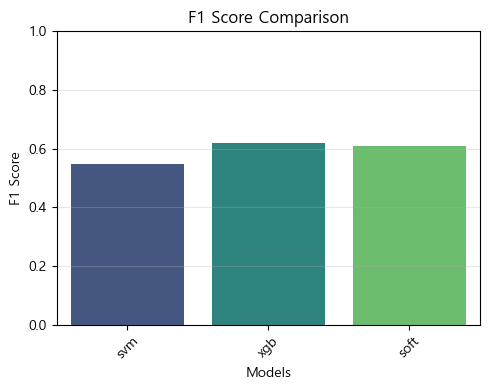

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

models = list(model_scores.keys())
f1_values = [model_scores[m]["f1"] for m in models]

plt.figure(figsize=(5,4))
sns.barplot(x=models, y=f1_values, palette="viridis")
plt.ylim(0, 1)
plt.title("F1 Score Comparison")
plt.ylabel("F1 Score")
plt.xlabel("Models")
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()



### Recall-only 비교

C:\Users\Playdata\AppData\Local\Temp\ipykernel_5348\2762413064.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=models, y=recall_values, palette="viridis")


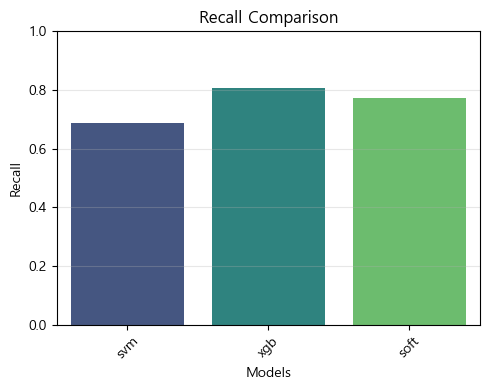

In [ ]:
recall_values = [model_scores[m]["recall"] for m in models]

plt.figure(figsize=(5,4))
sns.barplot(x=models, y=recall_values, palette="viridis")
plt.ylim(0, 1)
plt.title("Recall Comparison")
plt.ylabel("Recall")
plt.xlabel("Models")
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


### Pericision-only 비교

C:\Users\Playdata\AppData\Local\Temp\ipykernel_5348\3357089439.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=models, y=precision_values, palette="viridis")


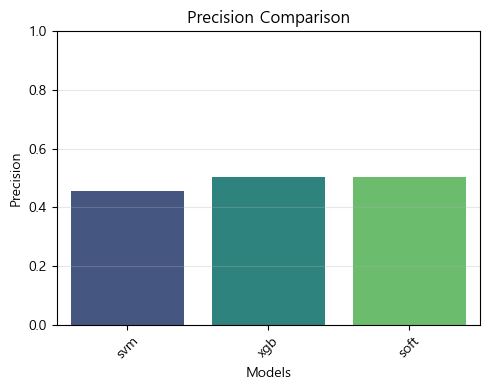

In [ ]:
precision_values = [model_scores[m]["precision"] for m in models]

plt.figure(figsize=(5,4))
sns.barplot(x=models, y=precision_values, palette="viridis")
plt.ylim(0, 1)
plt.title("Precision Comparison")
plt.ylabel("Precision")
plt.xlabel("Models")
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


# SHAP 기반 모델 해석
* SVM은 SHAP이 잘 안 맞고 속도도 매우 느려서 XGBoost / LightGBM / RandomForest 중심으로 진행

In [ ]:
import shap

# SHAP Explainer 생성 (XGBoost용)
explainer = shap.TreeExplainer(best_xgb)

# SHAP 값 계산
shap_values = explainer.shap_values(X_test_scaled)

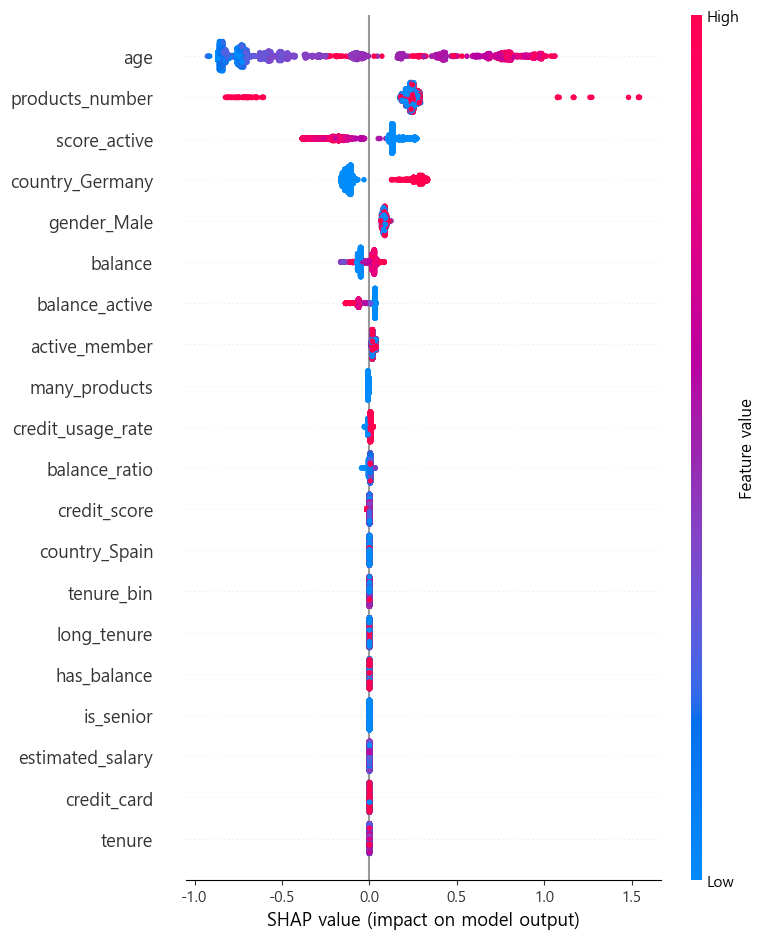

In [ ]:
shap.summary_plot(shap_values, X_test_scaled, feature_names=X_test.columns)

# 어떤 feature가 예측에 영향을 가장 많이 줬는지

# 값이 커지면 이탈(1)에 어떤 방향으로 영향을 주는지

# 색(blue→red)로 값의 크기 표현

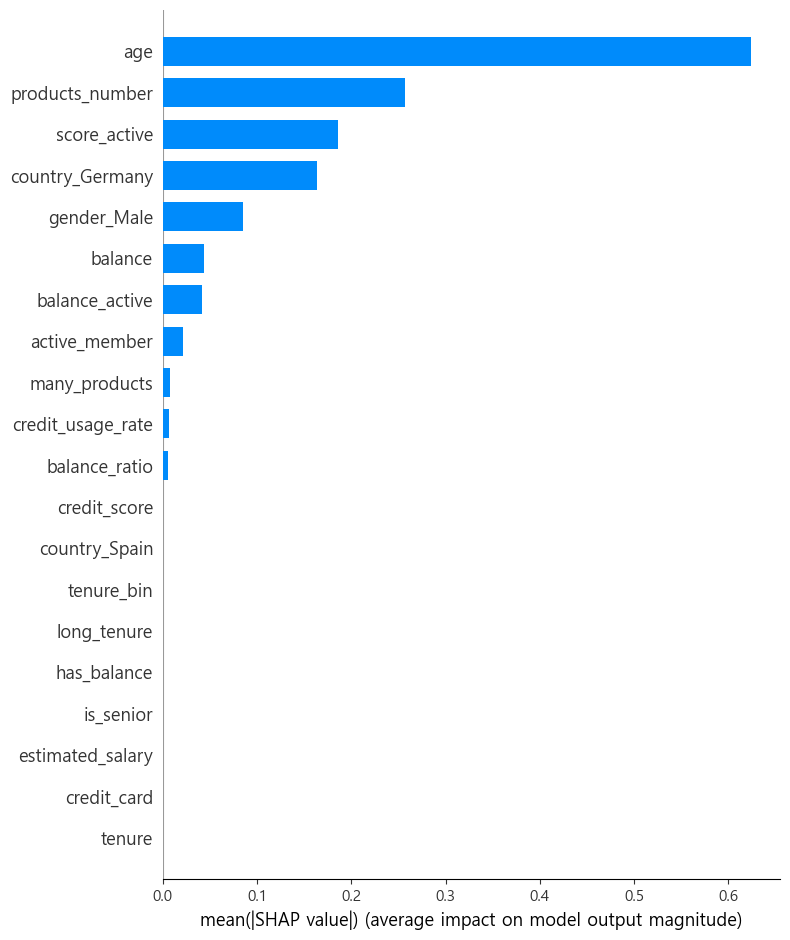

In [ ]:
shap.summary_plot(shap_values, X_test_scaled, feature_names=X_test.columns, plot_type="bar")

# 각 feature가 모델을 얼마나 움직였는가를 단순하게 보여주는 그래프

In [1]:
shap.dependence_plot("age", shap_values, X_test_scaled, feature_names=X_test.columns)
# 이건 “한 feature의 값에 따라 이탈 확률이 어떻게 변하는지”를 보여줌.

# 예: “Tenure(고객 계약기간)가 짧으면 이탈 확률 증가하는가?”

# 빨간 점 = 해당 feature 값이 큰 고객

# y축 = 이탈 예측에 기여한 정도

# 점들이 오른쪽 위로 몰리면 → 값이 클수록 이탈 확률 증가

# 점들이 왼쪽 아래로 몰리면 → 값이 커질수록 이탈 확률 감

NameError: name 'shap' is not defined

# model save

In [141]:
import joblib

artifacts = {
    "scaler": scaler,
    "svm": best_svm,
    "xgb": best_xgb,
    "th_svm": best_th_svm,
    "th_xgb": best_th_xgb,
    "th_soft": best_th_soft,
    "feature_cols": X.columns.tolist()   # 전처리 후 feature column 목록 저장
}

joblib.dump(artifacts, "churn_models.pkl")
print("저장 완료: churn_models.pkl")


저장 완료: churn_models.pkl


## model load

In [142]:
import pandas as pd

def preprocess(df):
    df = df.copy()

    # --- ratio ---
    eps = 1e-3
    df["balance_ratio"] = df["balance"] / (df["estimated_salary"] + eps)
    df["credit_usage_rate"] = df["balance"] / (df["credit_score"] + eps)
    df["credit_usage_rate"] = df["credit_usage_rate"].clip(-10, 10)

    # --- Tenure bin ---
    df["tenure_bin"] = pd.cut(
        df["tenure"], bins=[-1, 3, 7, 100],
        labels=[0, 1, 2]
    ).astype(int)

    # --- Boolean / indicator ---
    df["is_senior"] = (df["age"] >= 60).astype(int)
    df["has_balance"] = (df["balance"] > 0).astype(int)
    df["many_products"] = (df["products_number"] >= 3).astype(int)
    df["long_tenure"] = (df["tenure"] >= 7).astype(int)

    # --- Interaction ---
    df["score_active"] = df["credit_score"] * df["active_member"]
    df["balance_active"] = df["balance"] * df["active_member"]

    # --- One-hot ---
    df["gender_Male"] = (df["gender"] == "Male").astype(int)
    df["country_Germany"] = (df["country"] == "Germany").astype(int)
    df["country_Spain"] = (df["country"] == "Spain").astype(int)

    return df


In [143]:
import joblib

artifacts = joblib.load("churn_models.pkl")

scaler       = artifacts["scaler"]
svm          = artifacts["svm"]
xgb          = artifacts["xgb"]
th_svm       = artifacts["th_svm"]
th_xgb       = artifacts["th_xgb"]
th_soft      = artifacts["th_soft"]
feature_cols = artifacts["feature_cols"]


In [144]:
df_new = pd.read_csv("Bank Customer Churn Prediction.csv")

# 1) 전처리
df_new_processed = preprocess(df_new)

# 2) 학습 당시 feature순서 맞추기
X_new = df_new_processed[feature_cols]

# 3) 스케일링
X_new_scaled = scaler.transform(X_new)


In [145]:
proba_svm = svm.predict_proba(X_new_scaled)[:, 1]
pred_svm = (proba_svm >= th_svm).astype(int)


In [146]:
proba_xgb = xgb.predict_proba(X_new_scaled)[:, 1]
pred_xgb = (proba_xgb >= th_xgb).astype(int)

In [147]:
proba_soft = 0.5*proba_svm + 0.5*proba_xgb
pred_soft = (proba_soft >= th_soft).astype(int)

In [148]:
df_new["proba_svm"] = proba_svm
df_new["proba_xgb"] = proba_xgb
df_new["proba_soft"] = proba_soft

df_new["pred_svm"] = pred_svm
df_new["pred_xgb"] = pred_xgb
df_new["pred_soft"] = pred_soft

df_new.to_csv("churn_predictions_result.csv", index=False)
print("예측 결과 저장됨 → churn_predictions_result.csv")


예측 결과 저장됨 → churn_predictions_result.csv


In [149]:
df_new[["proba_svm", "proba_xgb", "proba_soft"]].describe()


,proba_svm,proba_xgb,proba_soft
count,10000.000000,10000.000000,10000.000000
mean,0.204658,0.512528,0.358593
std,0.199339,0.285354,0.227484
min,0.003391,0.026326,0.015207
25%,0.056655,0.253932,0.166613
50%,0.129153,0.510252,0.330239
75%,0.295920,0.754937,0.512968
max,0.974466,0.999145,0.982657


In [150]:
df_new["pred_soft"].value_counts()


pred_soft
0    7342
1    2658
Name: count, dtype: int64

In [151]:
df_soft = df_new[[
    "customer_id",
    "proba_soft",
    "pred_soft"
]]

df_soft.head(15)


,customer_id,proba_soft,pred_soft
0,15634602,0.459857,0
1,15647311,0.422901,0
2,15619304,0.913589,1
3,15701354,0.239970,0
4,15737888,0.360696,0
5,15574012,0.384543,0
6,15592531,0.191892,0
7,15656148,0.827088,1
8,15792365,0.198254,0
9,15592389,0.145382,0
